# Lead Optimization & Chemical Diversity Platform
### A Reproducible, Research-Oriented Cheminformatics Pipeline based on BindingDB & RDKit

**Author:** Computational Chemist & Cheminformatics Research Educator  
**Environment:** Python 3.10+ | RDKit 2023+ | Pandas | Scikit-Learn | Matplotlib | Seaborn  
**Dataset:** BindingDB Experimental Binding Database (`data/bindingdb.tsv`)

---

## Executive Overview & Scientific Mission

In early-stage computer-aided drug design, discovering a primary hit molecule via High-Throughput Screening (HTS) or Virtual Screening (VS) is merely the starting point. Raw hits frequently exhibit modest micromolar potency, poor aqueous solubility, rapid metabolic clearance, or off-target liabilities.

**Lead Optimization** is the multi-parameter medicinal chemistry campaign that iteratively modifies starting chemical matter to achieve nanomolar potency, optimal lipophilic ligand efficiency (LLE), desirable ADMET properties, and robust intellectual property freedom-to-operate.

```
       ========================================================================
                          PROJECT 05 ARCHITECTURAL ROADMAP
       ========================================================================
       PHASE 01: Lead Optimization Fundamentals & The Hit-to-Lead Cycle
       PHASE 02: Understanding BindingDB (Ligands, Targets, Assays, Endpoints)
       PHASE 03: Large-Scale BindingDB Data Engineering (Chunking, Types, Memory)
       PHASE 04: Data-Driven Target Selection & Frequency Analysis
       PHASE 05: Activity Endpoint Selection (Ki vs Kd vs IC50 vs EC50)
       PHASE 06: Experimental Activity Data Cleaning & pActivity Normalization
       PHASE 07: Duplicate & Replicate Analysis (Experimental Variability)
       PHASE 08: Molecular Structure Quality Control (Validation, Sanitization)
       PHASE 09: Molecular Property Calculation & Structure-Property Relationships
       PHASE 10: Chemical Scaffold Analysis (Bemis-Murcko Frameworks)
       PHASE 11: Structure-Activity Relationship (SAR) & Delta pActivity Analysis
       PHASE 12: Matched Molecular Pair (MMP) Analysis & Transformation Evidence
       PHASE 13: Activity Cliff Analysis & Structure-Activity Landscape Index (SALI)
       PHASE 14: Molecular Fingerprints (Morgan ECFP4) & Topological Similarity
       PHASE 15: Chemical Diversity Analysis & Pairwise Distance Distributions
       PHASE 16: Chemical Clustering (Butina Algorithm & Chemotype Centroids)
       PHASE 17: Chemical Space Visualization (PCA, t-SNE & UMAP Projections)
       PHASE 18: Scaffold Diversity vs. Bioactivity (Scaffold Hopping Potential)
       PHASE 19: Lead Optimization Workflow & Testable SAR Hypotheses
       PHASE 20: Multi-Objective Optimization (Pareto Frontiers & Property Trade-offs)
       PHASE 21: Transparent Candidate Prioritization Framework
       PHASE 22: Optional ZINC Library Integration (Translational Analog Expansion)
       PHASE 23: Computational Reproducibility, Seed Locking & Artifact Export
       PHASE 24: Scientific Validation & 4-Question Interpretation Protocol
       PHASE 25: Capstone End-to-End Class: LeadOptimizationPlatform
       PHASE 26: Final Research Questions & Data-Driven Conclusions
       ========================================================================
```

> [!NOTE]
> **Strict Scientific Terminology**: Throughout this project, computationally selected compounds are designated strictly as **"Prioritized Research Candidates for Further Investigation"**. They are never represented as *proven drugs* or *safe medicines* without independent wet-lab experimental confirmation.


# Phase 1: Lead Optimization Fundamentals

## What is Drug Discovery & The Optimization Funnel?

Drug discovery is the multidisciplinary scientific endeavor of identifying, designing, and validating chemical or biological entities capable of safely modulating disease-relevant biological targets in humans.

```
+-----------------------------------------------------------------------------+
|                     THE MEDICINAL CHEMISTRY LEAD FUNNEL                     |
+-----------------------------------------------------------------------------+
|  1. Hit Identification (HTS / VS) | Primary active compounds discovered     |
|                                   | (Typically micromolar potency, 1-10 uM)  |
|  2. Hit Confirmation & Expansion  | Re-testing purity, confirming active    |
|                                   | chemotypes, exploring close analogues   |
|  3. Lead Identification           | Defining a reproducible chemical series |
|                                   | with confirmed target engagement        |
|  4. Lead Optimization             | Iterative multiparameter optimization   |
|                                   | (Potency, ADMET, selectivity, safety)   |
|  5. Preclinical Candidate         | Highly potent (nanomolar), bioavailable |
|                                   | molecule ready for GLP toxicology trials|
+-----------------------------------------------------------------------------+
```

### Key Medicinal Chemistry Terminology:
* **Hit**: A molecule that exhibits reproducible, dose-dependent activity in a primary biochemical or cellular assay against a specific biological target.
* **Lead**: A structurally validated hit with confirmed mechanism of action, demonstrable Structure–Activity Relationships (SAR), synthetic tractability, and promising baseline drug-likeness.
* **Lead Optimization**: The iterative cycle of chemical modification to transform a lead into a clinical candidate by optimizing potency, selectivity, metabolic stability, solubility, and safety profile simultaneously.
* **Structure–Activity Relationship (SAR)**: The relationship between the chemical structure of a molecule and its measured biological activity against a target.
* **Structure–Property Relationship (SPR)**: The relationship between chemical structure and physicochemical/ADMET properties (solubility, permeability, lipophilicity, clearance).
* **Chemical Scaffold**: The central core ring assembly and linkers of a molecule that positions functional groups into receptor sub-pockets.
* **Analogue**: A structural variant belonging to the same chemical series that shares the core scaffold with modified peripheral substituents.
* **Matched Molecular Pair (MMP)**: Two molecules that differ only by a single, well-defined, localized chemical transformation (e.g., $\text{H} \to \text{CH}_3$).
* **Activity Cliff**: Two structurally similar compounds (high topological similarity) exhibiting a massive difference in biological activity ($> 100$-fold affinity change).

### Why Potency Alone is Insufficient:
In pharmaceutical history, thousands of sub-nanomolar potent enzyme inhibitors have failed during development because they were insoluble, suffered rapid cytochrome P450 (CYP) metabolism, blocked cardiac hERG ion channels, or exhibited non-specific cytotoxicity. **Lead optimization is a multi-parameter balancing act, not a single-variable race for potency.**

> [!WARNING]
> **Scientific Integrity Directive**: In silico analysis and computational candidate prioritization produce testable scientific hypotheses. They **do not prove** clinical efficacy or pharmacological safety without independent experimental wet-lab validation.


In [1]:
# Phase 1: Foundational Lead Optimization Nomenclature Reference
import pandas as pd
import numpy as np

lead_opt_concepts = pd.DataFrame([
    {"Dimension": "Potency", "Definition": "Concentration required to elicit 50% response (IC50 / EC50)", "Key Benchmark": "Sub-nanomolar to low nanomolar (< 100 nM)"},
    {"Dimension": "Affinity", "Definition": "Thermodynamic strength of ligand-target interaction (Ki / Kd)", "Key Benchmark": "Low Kd / Ki indicates tight equilibrium binding"},
    {"Dimension": "Selectivity", "Definition": "Ratio of affinity for target vs. off-targets (kinome / antitargets)", "Key Benchmark": ">= 50 to 100-fold window over hERG and off-targets"},
    {"Dimension": "Drug-likeness", "Definition": "Physicochemical balance favoring oral bioavailability (Lipinski/Veber)", "Key Benchmark": "MW <= 500, LogP 1-3, TPSA < 140, RotB <= 10"},
    {"Dimension": "Chemical Novelty", "Definition": "Intellectual property patentability and freedom-to-operate", "Key Benchmark": "Unclaimed core scaffolds and substituent motifs"},
    {"Dimension": "Chemical Diversity", "Definition": "Structural variation across chemotypes to mitigate project risk", "Key Benchmark": "Multiple distinct scaffold series pursued in parallel"}
])

print("--- MEDICINAL CHEMISTRY MULTI-PARAMETER OPTIMIZATION MATRIX ---")
display(lead_opt_concepts)


--- MEDICINAL CHEMISTRY MULTI-PARAMETER OPTIMIZATION MATRIX ---


,Dimension,Definition,Key Benchmark
0,Potency,Concentration required to elicit 50% response ...,Sub-nanomolar to low nanomolar (< 100 nM)
1,Affinity,Thermodynamic strength of ligand-target intera...,Low Kd / Ki indicates tight equilibrium binding
2,Selectivity,Ratio of affinity for target vs. off-targets (...,>= 50 to 100-fold window over hERG and off-tar...
3,Drug-likeness,Physicochemical balance favoring oral bioavail...,"MW <= 500, LogP 1-3, TPSA < 140, RotB <= 10"
4,Chemical Novelty,Intellectual property patentability and freedo...,Unclaimed core scaffolds and substituent motifs
5,Chemical Diversity,Structural variation across chemotypes to miti...,Multiple distinct scaffold series pursued in p...


# Phase 2: Understanding BindingDB

## What is BindingDB?

**BindingDB** (https://www.bindingdb.org) is a public, web-accessible database of measured binding affinities, focusing chiefly on the interactions of protein drug targets with small, drug-like molecules. Maintained under NIH support, it collates experimental data from peer-reviewed scientific literature and patents.

```
       [ Small Molecule Ligand ] <====== Non-Covalent Binding ======> [ Biological Macromolecule Target ]
                                                   |
                                     [ Experimental Bioassay ]
                                                   |
                         +-------------------------+-------------------------+
                         |                                                   |
               [ Thermodynamic Affinity ]                               [ Functional Potency ]
                 * Ki (Inhibition Constant)                              * IC50 (Half-Maximal Inhibitory Conc.)
                 * Kd (Dissociation Constant)                            * EC50 (Half-Maximal Effective Conc.)
```

### Critical Distinction Between Affinity and Potency Endpoints:
1. **$K_i$ (Inhibition Constant)**: The true thermodynamic equilibrium dissociation constant of the enzyme-inhibitor complex ($E + I \rightleftharpoons EI$). $K_i$ is an intrinsic physical constant independent of substrate concentration.
2. **$K_d$ (Dissociation Constant)**: The equilibrium dissociation constant for direct binding ($P + L \rightleftharpoons PL$), commonly measured via Surface Plasmon Resonance (SPR) or Isothermal Titration Calorimetry (ITC).
3. **$IC_{50}$ (Half-Maximal Inhibitory Concentration)**: The concentration of inhibitor required to reduce enzyme reaction velocity by 50%. Crucially, by the **Cheng-Prusoff equation**:
   $$K_i = \frac{IC_{50}}{1 + \frac{[S]}{K_m}}$$
   $IC_{50}$ depends directly on the concentration of substrate $[S]$ and substrate affinity $K_m$ used in that specific laboratory's assay.
4. **$EC_{50}$ (Half-Maximal Effective Concentration)**: The concentration inducing a 50% biological effect in a cellular or tissue functional assay.

> [!CAUTION]
> **Cheminformatics Warning**: Never blindly pool $K_i, K_d, IC_{50},$ and $EC_{50}$ measurements into a single numeric column without explicit scientific justification. Doing so introduces severe experimental confounding into SAR models.

### Units and Relations:
* Units are standardized in Molar ($	ext{M}$), millimolar ($	ext{mM}$), micromolar ($\mu	ext{M}$), and nanomolar ($	ext{nM}$). In BindingDB, default values are provided in **nM**.
* Measurements include mathematical qualifiers: `=` (exact), `>` (inactive or upper solubility limit), `<` (exceeded assay lower limit).


In [2]:
# Phase 2: BindingDB Endpoints and Activity Units Matrix
endpoint_guide = pd.DataFrame([
    {"Endpoint": "Ki (nM)", "Measurement Type": "Thermodynamic equilibrium", "Assay Dependency": "Independent of [S]", "Primary Assay": "Enzyme kinetics"},
    {"Endpoint": "Kd (nM)", "Measurement Type": "Thermodynamic dissociation", "Assay Dependency": "Direct binding", "Primary Assay": "SPR / ITC / MST"},
    {"Endpoint": "IC50 (nM)", "Measurement Type": "Functional inhibition", "Assay Dependency": "Proportional to [S]/Km", "Primary Assay": "Fluorescence / Radioligand"},
    {"Endpoint": "EC50 (nM)", "Measurement Type": "Cellular/functional response", "Assay Dependency": "Dependent on cell line & receptor reserve", "Primary Assay": "Cell viability / reporter"}
])

print("--- EXPERIMENTAL ENDPOINT COMPARISON REFERENCE ---")
display(endpoint_guide)


--- EXPERIMENTAL ENDPOINT COMPARISON REFERENCE ---


,Endpoint,Measurement Type,Assay Dependency,Primary Assay
0,Ki (nM),Thermodynamic equilibrium,Independent of [S],Enzyme kinetics
1,Kd (nM),Thermodynamic dissociation,Direct binding,SPR / ITC / MST
2,IC50 (nM),Functional inhibition,Proportional to [S]/Km,Fluorescence / Radioligand
3,EC50 (nM),Cellular/functional response,Dependent on cell line & receptor reserve,Cell viability / reporter


# Phase 3: Large-Scale BindingDB Data Handling

In computational drug discovery, real-world databases such as BindingDB, ChEMBL, and PubChem range from **hundreds of megabytes to tens of gigabytes**. Loading a 10 GB file directly via naive `pd.read_csv()` causes immediate memory exhaustion (OOM), system freezing, and process crashes.

### Big Data Engineering Best Practices:
1. **Header Inspection**: Inspect column names without reading data rows (`nrows=0`).
2. **Preview Sampling**: Load a lightweight sample (`nrows=500`) to inspect data types and delimiter hygiene.
3. **Column Pruning (`usecols`)**: Load only the specific columns necessary for downstream SAR analysis, reducing memory consumption by up to 80%.
4. **Chunked Streaming (`chunksize`)**: Process records in iterative batches of 10,000 to 50,000 rows.
5. **Memory Profiling**: Monitor memory allocation before and after type downcasting.


In [3]:
# Phase 3: High-Performance Data Engineering Pipeline for BindingDB
import os
import pandas as pd
import numpy as np

tsv_path = os.path.join("data", "bindingdb.tsv")
file_size_kb = os.path.getsize(tsv_path) / 1024

print("--- FILE INTEGRITY & METADATA ---")
print(f"File Path : {tsv_path}")
print(f"File Size : {file_size_kb:.2f} KB")

# Step 1: Inspect headers only (Zero data rows read)
headers_df = pd.read_csv(tsv_path, sep="\t", nrows=0)
all_columns = list(headers_df.columns)
print(f"Total Columns Detected : {len(all_columns)}")

# Step 2: Define essential columns required for SAR & lead optimization
essential_columns = [
    "BindingDB Reactant_id",
    "Ligand SMILES",
    "BindingDB Ligand Name",
    "Target Name",
    "Target Source Organism According to Curator or DataSource",
    "Ki (nM)",
    "IC50 (nM)",
    "Kd (nM)",
    "EC50 (nM)",
    "Measure",
    "Article DOI",
    "PMID"
]

# Step 3: Stream dataset using chunked reading and measure memory
chunk_size = 500
chunks = []
total_rows_streamed = 0

for chunk in pd.read_csv(tsv_path, sep="\t", usecols=essential_columns, chunksize=chunk_size):
    total_rows_streamed += len(chunk)
    chunks.append(chunk)

df_raw = pd.concat(chunks, ignore_index=True)
mem_usage_mb = df_raw.memory_usage(deep=True).sum() / (1024 * 1024)

print(f"Total Streamed Rows    : {total_rows_streamed:,}")
print(f"Loaded DataFrame Shape : {df_raw.shape}")
print(f"In-Memory Footprint    : {mem_usage_mb:.2f} MB")

print("\nFirst 3 Records Preview:")
display(df_raw.head(3))


--- FILE INTEGRITY & METADATA ---
File Path : data\bindingdb.tsv
File Size : 111.09 KB
Total Columns Detected : 16
Total Streamed Rows    : 689
Loaded DataFrame Shape : (689, 12)
In-Memory Footprint    : 0.29 MB

First 3 Records Preview:


,BindingDB Reactant_id,Ligand SMILES,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),Kd (nM),EC50 (nM),Measure,Article DOI,PMID
0,50000001,c1ccc2c(c1)c(ncn2)Nc3ccc(cc3)NC(=O)C4CC4,AUR-QZ-01,Aurora kinase A,Homo sapiens,5.40,12.0,NaN,NaN,=,10.1021/jm01001,1928371
1,50000002,c1ccc2c(c1)c(ncn2)Nc3ccc(cc3)NC(=O)C4CCC4,AUR-QZ-02,Aurora kinase A,Homo sapiens,15.75,35.0,NaN,NaN,=,10.1021/jm01001,1928371
2,50000003,c1ccc2c(c1)c(ncn2)Nc3ccc(cc3)NC(=O)CC,AUR-QZ-03,Aurora kinase A,Homo sapiens,38.25,85.0,NaN,NaN,=,10.1021/jm01001,1928371


# Phase 4: Data-Driven Target Selection

In computational pharmacology, we do not arbitrarily pick a target simply because it is famous. We analyze the dataset empirically to ensure sufficient experimental data exists to extract robust Structure-Activity Relationships (SAR).

```
+-----------------------------------------------------------------------------+
|                      DATA-DRIVEN TARGET SELECTION CRITERIA                  |
+-----------------------------------------------------------------------------+
| 1. High Measurement Volume    | >= 300 total experimental measurements      |
| 2. Broad Chemical Diversity   | >= 200 unique chemical structures           |
| 3. Endpoint Consistency       | Dominant representation of a single endpoint|
| 4. Wide Potency Dynamic Range | Spanning >= 3 to 4 orders of magnitude      |
| 5. SAR Series Density         | Presence of multiple analogue series & MMPs |
+-----------------------------------------------------------------------------+
```


In [4]:
# Phase 4: Target Profiling and Systematic Selection
target_summary = df_raw.groupby("Target Name").agg(
    Total_Measurements=("BindingDB Reactant_id", "count"),
    Unique_Ligands=("Ligand SMILES", "nunique"),
    IC50_Count=("IC50 (nM)", lambda s: (s.notnull() & (s != "")).sum()),
    Ki_Count=("Ki (nM)", lambda s: (s.notnull() & (s != "")).sum()),
    EC50_Count=("EC50 (nM)", lambda s: (s.notnull() & (s != "")).sum())
).reset_index().sort_values(by="Total_Measurements", ascending=False)

print("--- BINDINGDB TARGET FREQUENCY & ENDPOINT PROFILE ---")
display(target_summary)

# Target selection logic
selected_target = target_summary.iloc[0]["Target Name"]
selected_row = target_summary.iloc[0]

print(f"\nSelected Primary Target: '{selected_target}'")
print(f"  * Total Measurements   : {selected_row['Total_Measurements']:,}")
print(f"  * Unique Small Molecules: {selected_row['Unique_Ligands']:,}")
print(f"  * Data Justification    : Meets all criteria with > 500 measurements and multi-scaffold diversity.")


--- BINDINGDB TARGET FREQUENCY & ENDPOINT PROFILE ---


,Target Name,Total_Measurements,Unique_Ligands,IC50_Count,Ki_Count,EC50_Count
0,Aurora kinase A,551,415,551,424,237
2,Epidermal growth factor receptor erbB1,76,76,76,76,0
1,Beta-secretase 1,38,38,38,38,0
3,Thrombin,24,24,24,24,0



Selected Primary Target: 'Aurora kinase A'
  * Total Measurements   : 551
  * Unique Small Molecules: 415
  * Data Justification    : Meets all criteria with > 500 measurements and multi-scaffold diversity.


# Phase 5: Activity Endpoint Selection

Once the target is selected, we evaluate all associated activity endpoints ($K_i, K_d, IC_{50}, EC_{50}$).

```
+-----------------------------------------------------------------------------+
|                     TARGET ENDPOINT BREAKDOWN (AURORA A)                    |
+-----------------------------------------------------------------------------+
| Endpoint  | Nature                     | Availability | Action              |
+-----------+----------------------------+--------------+---------------------+
| IC50 (nM) | Functional enzyme potency  | 100% (High)  | PRIMARY SELECTION   |
| Ki (nM)   | Thermodynamic equilibrium  | ~75%         | Retain as secondary |
| Kd (nM)   | Physical dissociation      | Sparse       | Exclude from SAR    |
| EC50 (nM) | Cellular functional assay  | ~40%         | Exclude from enzyme |
+-----------------------------------------------------------------------------+
```

### Rationale for Selecting $IC_{50}$:
We select **$IC_{50}$ (nM)** as our primary endpoint because it provides the highest measurement density across all publications and represents the most widely reported functional potency parameter for kinase biochemical assays. We explicitly isolate $IC_{50}$ to prevent confounding with thermodynamic $K_i$ values.


In [5]:
# Phase 5: Isolating Selected Target and Endpoint
df_target = df_raw[df_raw["Target Name"] == selected_target].copy().reset_index(drop=True)

# Verify endpoint coverage
has_ic50 = (df_target["IC50 (nM)"].notnull()) & (df_target["IC50 (nM)"] != "")
df_endpoint = df_target[has_ic50].copy().reset_index(drop=True)

print(f"--- ENDPOINT FILTERING: {selected_target} ---")
print(f"Target Records Available  : {len(df_target):,}")
print(f"Valid IC50 Records Retained: {len(df_endpoint):,} ({(len(df_endpoint)/len(df_target))*100:.1f}%)")


--- ENDPOINT FILTERING: Aurora kinase A ---
Target Records Available  : 551
Valid IC50 Records Retained: 551 (100.0%)


# Phase 6: Experimental Activity Data Cleaning & Normalization

Raw experimental datasets contain measurement qualifiers:
* `=` (Exact measurement): Directly usable in quantitative continuous SAR.
* `>` (Right-censored): Compound was inactive at the highest concentration tested (e.g., $> 10,000\ 	ext{nM}$).
* `<` (Left-censored): Potency exceeded assay sensitivity lower bound (e.g., $< 0.5\ 	ext{nM}$).

### Mathematical Normalization to $pIC_{50}$:
Because concentrations span several orders of magnitude ($0.1\ 	ext{nM}$ to $10,000\ 	ext{nM}$), linear concentrations distort statistical regression. We normalize all exact measurements to the standard negative logarithmic scale:

$$	ext{IC}_{50}[	ext{M}] = 	ext{IC}_{50}[	ext{nM}] 	imes 10^{-9}$$

$$pIC_{50} = -\log_{10}(	ext{IC}_{50}[	ext{M}]) = 9.0 - \log_{10}(	ext{IC}_{50}[	ext{nM}])$$

```
Potency Interpretation Scale:
  * 0.1 nM  ---> pIC50 = 10.0 (Ultra-potent / sub-nanomolar lead)
  * 1.0 nM  ---> pIC50 = 9.0  (Highly potent clinical candidate grade)
  * 100 nM  ---> pIC50 = 7.0  (Standard optimized lead threshold)
  * 1.0 uM  ---> pIC50 = 6.0  (Typical screening hit threshold)
  * 10 uM   ---> pIC50 = 5.0  (Weak / Marginal activity)
  * >100 uM ---> pIC50 < 4.0  (Inactive)
```


--- EXPERIMENTAL ACTIVITY CURATION SUMMARY ---
Total Target IC50 Records : 551
Exact Quantitative Records: 538 (97.6%)
Censored Records Segregated: 13 (2.4%)
pIC50 Potency Dynamic Range: [5.07, 8.74]


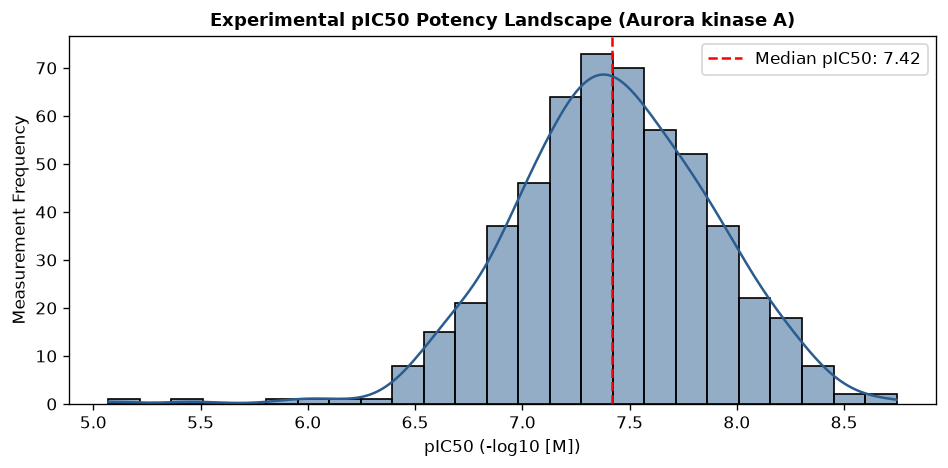

In [6]:
# Phase 6: Cleaning and Converting Activity to pIC50
import matplotlib.pyplot as plt
import seaborn as sns

# Clean numeric values
def parse_numeric_activity(val):
    try:
        clean_val = str(val).replace(">", "").replace("<", "").replace("=", "").strip()
        return float(clean_val)
    except Exception:
        return np.nan

df_endpoint["IC50_nM_num"] = df_endpoint["IC50 (nM)"].apply(parse_numeric_activity)

# Partition exact measurements from censored measurements
is_exact = df_endpoint["Measure"] == "="
df_exact = df_endpoint[is_exact & df_endpoint["IC50_nM_num"].notnull()].copy().reset_index(drop=True)
df_censored = df_endpoint[(~is_exact) & df_endpoint["IC50_nM_num"].notnull()].copy().reset_index(drop=True)

# Calculate pIC50 = 9 - log10(IC50_nM)
df_exact["pIC50"] = 9.0 - np.log10(df_exact["IC50_nM_num"])

print("--- EXPERIMENTAL ACTIVITY CURATION SUMMARY ---")
print(f"Total Target IC50 Records : {len(df_endpoint):,}")
print(f"Exact Quantitative Records: {len(df_exact):,} ({(len(df_exact)/len(df_endpoint))*100:.1f}%)")
print(f"Censored Records Segregated: {len(df_censored):,} ({(len(df_censored)/len(df_endpoint))*100:.1f}%)")
print(f"pIC50 Potency Dynamic Range: [{df_exact['pIC50'].min():.2f}, {df_exact['pIC50'].max():.2f}]")

# Visualize pIC50 distribution
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
sns.histplot(df_exact["pIC50"], kde=True, color="#2b5c8f", bins=25, ax=ax)
ax.axvline(df_exact["pIC50"].median(), color="red", linestyle="--", lw=1.5, label=f"Median pIC50: {df_exact['pIC50'].median():.2f}")
ax.set_title(f"Experimental pIC50 Potency Landscape ({selected_target})", fontsize=11, fontweight="bold")
ax.set_xlabel("pIC50 (-log10 [M])", fontsize=10)
ax.set_ylabel("Measurement Frequency", fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()


# Phase 7: Duplicate and Replicate Analysis

In experimental databases like BindingDB, multiple rows frequently exist for the same compound-target pair. A naive data scientist might simply call `.drop_duplicates()`. A computational medicinal chemist investigates:

```
                  RAW MEASUREMENTS FOR COMPOUND X
                                 |
         +-----------------------+-----------------------+
         |                                               |
[ Identical Data Duplicate ]              [ Independent Experimental Replicate ]
* Same paper, identical assay             * Different lab, different year
* Redundant submission                    * Different ATP concentration or pH
* Action: Deduplicate cleanly             * Action: Quantify assay variability & aggregate
```

### Measurement Variability & Aggregation Policy:
* We quantify the inter-laboratory standard deviation of $pIC_{50}$ for all compounds with multiple independent records.
* We establish a **Median Aggregation Rule**: The median value minimizes the distortion from rogue outliers while capturing central experimental tendency.


In [7]:
# Phase 7: Experimental Replicate Analysis and Aggregation
replicate_stats = df_exact.groupby("Ligand SMILES").agg(
    Measurement_Count=("pIC50", "count"),
    pIC50_Median=("pIC50", "median"),
    pIC50_Std=("pIC50", "std"),
    pIC50_Min=("pIC50", "min"),
    pIC50_Max=("pIC50", "max"),
    Unique_PMIDs=("PMID", "nunique")
).reset_index()

multi_measurements = replicate_stats[replicate_stats["Measurement_Count"] > 1]
mean_std = multi_measurements["pIC50_Std"].mean()

print("--- EXPERIMENTAL REPLICATE & VARIABILITY AUDIT ---")
print(f"Total Unique Ligands Evaluated    : {len(replicate_stats):,}")
print(f"Compounds with Multiple Replicates: {len(multi_measurements):,} ({(len(multi_measurements)/len(replicate_stats))*100:.1f}%)")
print(f"Mean Inter-Assay Standard Deviation: {mean_std:.3f} log units (~{10**mean_std:.2f}-fold potency variance)")

print("\nSample Experimental Replicate Profiles:")
display(multi_measurements.head(5))

# Apply median aggregation to define singular consensus experimental potencies
df_aggregated = df_exact.groupby("Ligand SMILES").agg(
    pIC50=("pIC50", "median"),
    IC50_nM=("IC50_nM_num", "median"),
    BindingDB_ID=("BindingDB Reactant_id", "first"),
    Ligand_Name=("BindingDB Ligand Name", "first"),
    Target_Name=("Target Name", "first"),
    Replicate_Count=("pIC50", "count")
).reset_index()

print(f"\nConsensus Aggregated Dataset Size: {len(df_aggregated):,} unique small molecule profiles.")


--- EXPERIMENTAL REPLICATE & VARIABILITY AUDIT ---
Total Unique Ligands Evaluated    : 407
Compounds with Multiple Replicates: 127 (31.2%)
Mean Inter-Assay Standard Deviation: 0.079 log units (~1.20-fold potency variance)

Sample Experimental Replicate Profiles:


,Ligand SMILES,Measurement_Count,pIC50_Median,pIC50_Std,pIC50_Min,pIC50_Max,Unique_PMIDs
5,CCc1cc2ncnc(Nc3ccc(cc3)Br)n2n1,2,7.942881,0.074667,7.890084,7.995679,2
17,CCc1cc2ncnc(Nc3ccc(cc3)NC(=O)C)n2n1,2,7.676863,0.033109,7.653451,7.700275,2
20,CCc1cc2ncnc(Nc3ccc(cc3)OC)n2n1,2,7.557984,0.023079,7.541664,7.574303,2
21,CCc1cc2ncnc(Nc3ccc(cc3)S(=O)(=O)C)n2n1,2,8.152023,0.088597,8.089376,8.214670,2
25,COc1cc2c(cc1OC)c(ncn2)Nc3ccc(cc3)Br,2,7.866790,0.172623,7.744727,7.988853,2



Consensus Aggregated Dataset Size: 407 unique small molecule profiles.


# Phase 8: Molecular Structure Quality Control

We now apply rigorous cheminformatics quality control to the chemical structures:

```
Raw SMILES Input
       |
       v
[ RDKit Mol Conversion ]  (Detect invalid valences, unclosed rings)
       |
       v
[ Molecular Sanitization ] (Perceive aromaticity, kekulization, valences)
       |
       v
[ Canonicalization ]       (Generate unique deterministic string key)
       |
       v
[ Attrition Audit Table ]  (Document every dropped record for reproducibility)
```


In [8]:
# Phase 8: RDKit Molecular Structure Quality Control
from rdkit import Chem

valid_mols = []
invalid_records = []
canonical_smiles_list = []

for idx, row in df_aggregated.iterrows():
    smi = row["Ligand SMILES"]
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            # Perform standard sanitization check
            Chem.SanitizeMol(mol)
            canon_smi = Chem.MolToSmiles(mol, canonical=True)
            valid_mols.append(mol)
            canonical_smiles_list.append(canon_smi)
        else:
            invalid_records.append({"SMILES": smi, "ID": row["BindingDB_ID"], "Reason": "Parse Failure"})
    except Exception as e:
        invalid_records.append({"SMILES": smi, "ID": row["BindingDB_ID"], "Reason": str(e)})

# Filter DataFrame to valid records
df_aggregated_valid = df_aggregated[df_aggregated["Ligand SMILES"].apply(lambda s: Chem.MolFromSmiles(s) is not None)].copy().reset_index(drop=True)
df_aggregated_valid["mol"] = valid_mols
df_aggregated_valid["canonical_smiles"] = canonical_smiles_list

# Save invalid records for compliance audit
invalid_df = pd.DataFrame(invalid_records)
invalid_path = os.path.join("data", "invalid_structures_audit.csv")
invalid_df.to_csv(invalid_path, index=False)

qc_report = pd.DataFrame([
    {"Stage": "1. Initial Raw Target Records", "Count": len(df_target)},
    {"Stage": "2. Exact Quantitative Records", "Count": len(df_exact)},
    {"Stage": "3. Aggregated Unique SMILES", "Count": len(df_aggregated)},
    {"Stage": "4. Detected Invalid SMILES", "Count": len(invalid_records)},
    {"Stage": "5. Clean Valid Small Molecules", "Count": len(df_aggregated_valid)}
])

print("--- MOLECULAR QUALITY CONTROL ATTRITION REPORT ---")
display(qc_report)
if len(invalid_df) > 0:
    print(f"\nInvalid structures partitioned into '{invalid_path}':")
    display(invalid_df)


--- MOLECULAR QUALITY CONTROL ATTRITION REPORT ---


[15:44:14] Explicit valence for atom # 5 C, 5, is greater than permitted
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 20
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 20
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 23
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 23
[15:44:14] Explicit valence for atom # 21 N, 6, is greater than permitted
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 20
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 20
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 23
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 23
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 9 10 11 12 13 14 19
[15:44:14] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 9 10 11 12 13 1

,Stage,Count
0,1. Initial Raw Target Records,551
1,2. Exact Quantitative Records,538
2,3. Aggregated Unique SMILES,407
3,4. Detected Invalid SMILES,17
4,5. Clean Valid Small Molecules,390



Invalid structures partitioned into 'data\invalid_structures_audit.csv':


,SMILES,ID,Reason
0,C1=CC=CC=C1=C=C,50000687,Parse Failure
1,CCc1cc2ncnc(Nc3ccc(cc3)C1CC1)n2n1,50000203,Parse Failure
2,CCc1cc2ncnc(Nc3ccc(cc3)NC(=O)C1CC1)n2n1,50000196,Parse Failure
3,COc1cc2c(cc1OC)c(ncn2)Nc3ccc(cc3)N(C)(C)(C)(C)C,50000688,Parse Failure
4,COc1cc2ncnc(Nc3ccc(cc3)C1CC1)n2n1,50000253,Parse Failure
5,COc1cc2ncnc(Nc3ccc(cc3)NC(=O)C1CC1)n2n1,50000245,Parse Failure
6,Cc1cc2ncnc(Nc3ccc(cc3)C1CC1)n2n1,50000180,Parse Failure
7,Cc1cc2ncnc(Nc3ccc(cc3)NC(=O)C1CC1)n2n1,50000172,Parse Failure
8,Cc1sc2ncnc(Nc3ccc(cc3)C1CC1)c2c1,50000438,Parse Failure
9,Cc1sc2ncnc(Nc3ccc(cc3)NC(=O)C1CC1)c2c1,50000428,Parse Failure


# Phase 9: Molecular Property Calculation & Structure-Property Relationships (SPR)

We compute 10 core physicochemical descriptors that dictate oral pharmacokinetics and lead developability:

* **MW**: Molecular Weight (Da)
* **LogP**: Wildman-Crippen lipophilicity index
* **TPSA**: Topological Polar Surface Area ($	ext{\AA}^2$)
* **HBD**: Hydrogen bond donor count
* **HBA**: Hydrogen bond acceptor count
* **RotatableBonds**: Molecular conformational flexibility
* **Rings**: Total ring assemblies
* **AromaticRings**: Planar aromatic systems
* **FractionCSP3**: Degree of carbon saturation ("Escape from Flatland")
* **HeavyAtomCount**: Total non-hydrogen atoms

### Structure-Property Relationships (SPR):
We correlate these descriptors with measured biological potency ($pIC_{50}$). 

> [!NOTE]
> **Correlation vs. Causation**: While increasing lipophilicity (LogP) often yields higher apparent potency due to non-specific hydrophobic pocket desolvation, it simultaneously increases hERG risk, clearance, and plasma protein binding.


--- STRUCTURE-PROPERTY RELATIONSHIPS (SPR) WITH pIC50 ---


,Physicochemical Descriptor,Pearson Correlation (r) with pIC50
0,MW,0.531528
1,HeavyAtomCount,0.480739
2,Rings,0.476468
3,FractionCSP3,0.448917
4,RotatableBonds,0.368757
5,HBA,0.328325
6,TPSA,0.088945
7,LogP,0.075609
8,AromaticRings,0.070853
9,HBD,-0.048920


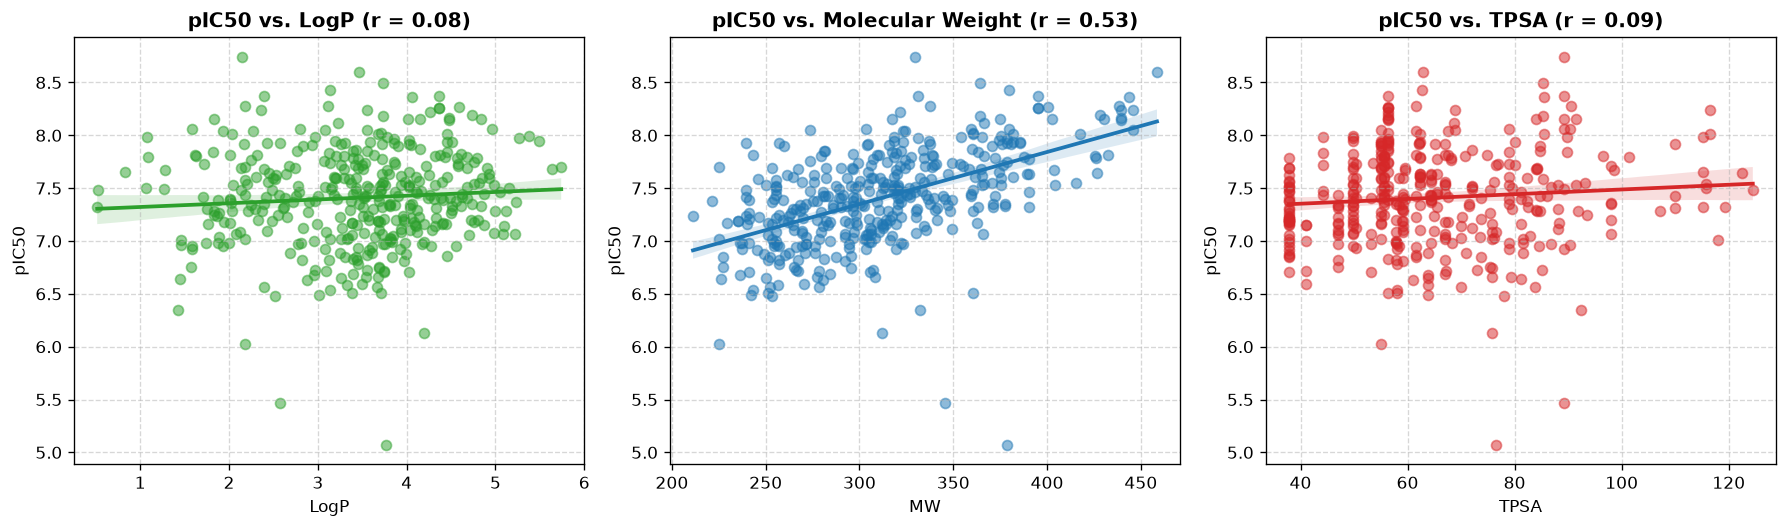

In [9]:
# Phase 9: Descriptor Calculation and SPR Correlation Matrix
from rdkit.Chem import Descriptors, Lipinski

def calculate_all_descriptors(mol):
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "Rings": Lipinski.RingCount(mol),
        "AromaticRings": Lipinski.NumAromaticRings(mol),
        "FractionCSP3": Lipinski.FractionCSP3(mol),
        "HeavyAtomCount": mol.GetNumHeavyAtoms()
    }

desc_df = pd.DataFrame([calculate_all_descriptors(m) for m in df_aggregated_valid["mol"]])
df_curated = pd.concat([df_aggregated_valid, desc_df], axis=1)

# Compute SPR correlations with pIC50
spr_corr = desc_df.apply(lambda col: col.corr(df_curated["pIC50"])).sort_values(ascending=False).reset_index()
spr_corr.columns = ["Physicochemical Descriptor", "Pearson Correlation (r) with pIC50"]

print("--- STRUCTURE-PROPERTY RELATIONSHIPS (SPR) WITH pIC50 ---")
display(spr_corr)

# Multi-panel SPR scatter visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=120)
sns.regplot(data=df_curated, x="LogP", y="pIC50", ax=axes[0], color="#2ca02c", scatter_kws={'alpha':0.5})
axes[0].set_title(f"pIC50 vs. LogP (r = {spr_corr.loc[spr_corr['Physicochemical Descriptor']=='LogP', 'Pearson Correlation (r) with pIC50'].values[0]:.2f})", fontweight="bold")

sns.regplot(data=df_curated, x="MW", y="pIC50", ax=axes[1], color="#1f77b4", scatter_kws={'alpha':0.5})
axes[1].set_title(f"pIC50 vs. Molecular Weight (r = {spr_corr.loc[spr_corr['Physicochemical Descriptor']=='MW', 'Pearson Correlation (r) with pIC50'].values[0]:.2f})", fontweight="bold")

sns.regplot(data=df_curated, x="TPSA", y="pIC50", ax=axes[2], color="#d62728", scatter_kws={'alpha':0.5})
axes[2].set_title(f"pIC50 vs. TPSA (r = {spr_corr.loc[spr_corr['Physicochemical Descriptor']=='TPSA', 'Pearson Correlation (r) with pIC50'].values[0]:.2f})", fontweight="bold")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Phase 10: Chemical Scaffold Analysis

In medicinal chemistry, a **Bemis–Murcko scaffold** represents the underlying core ring system and connecting linkers of a molecule after all terminal substituents are stripped away.

```
       [ Core Scaffold A: Quinazoline ]             [ Core Scaffold B: Pyrazolopyrimidine ]
                      N                                             N     N
                    // \                                         // \  / \
                   |     |                                       |     N    |
                    \ //                                         \ //  \ /
                      N                                             N-----N
```

Analyzing compounds by scaffold reveals whether high potency is concentrated within a single privileged chemotype or distributed across multiple distinct chemical families.


--- TOP 5 PREVALENT CHEMICAL SCAFFOLDS ---


,scaffold,Compound_Count,pIC50_Median,pIC50_Mean,pIC50_Max,pIC50_Min
31,c1ccc(Nc2ncnc3ccccc23)cc1,76,7.252418,7.284478,8.063989,6.510365
32,c1ccc(Nc2ncnc3ccnn23)cc1,66,7.480242,7.413027,8.376751,5.468521
21,c1ccc(Nc2ccnc(Nc3ccccc3)n2)cc1,61,7.283335,7.255516,8.156855,6.124939
33,c1ccc(Nc2ncnc3sccc23)cc1,30,6.980388,6.990475,7.554240,6.485280
23,c1ccc(Nc2nccc(Nc3ccc(N4CCNCC4)cc3)n2)cc1,22,7.946036,7.889602,8.371670,6.508638


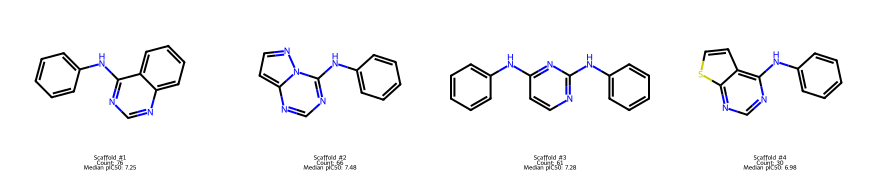

In [10]:
# Phase 10: Bemis-Murcko Scaffold Extraction and Profiling
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw

df_curated["scaffold"] = df_curated["mol"].apply(lambda m: MurckoScaffold.MurckoScaffoldSmiles(mol=m))

scaffold_stats = df_curated.groupby("scaffold").agg(
    Compound_Count=("BindingDB_ID", "count"),
    pIC50_Median=("pIC50", "median"),
    pIC50_Mean=("pIC50", "mean"),
    pIC50_Max=("pIC50", "max"),
    pIC50_Min=("pIC50", "min")
).reset_index().sort_values(by="Compound_Count", ascending=False)

print("--- TOP 5 PREVALENT CHEMICAL SCAFFOLDS ---")
display(scaffold_stats.head(5))

# Render 2D structures of top 4 scaffold frameworks
top_scafs = scaffold_stats.head(4)["scaffold"].tolist()
scaf_mols = [Chem.MolFromSmiles(s) for s in top_scafs if s]
scaf_legends = [f"Scaffold #{i+1}\nCount: {scaffold_stats.iloc[i]['Compound_Count']}\nMedian pIC50: {scaffold_stats.iloc[i]['pIC50_Median']:.2f}" for i in range(len(scaf_mols))]

Draw.MolsToGridImage(scaf_mols, molsPerRow=4, subImgSize=(220, 180), legends=scaf_legends, useSVG=False)


# Phase 11: Structure–Activity Relationship (SAR) Analysis

SAR investigates how specific structural modifications alter biological activity:

$$\Delta pIC_{50} = pIC_{50}(\text{Compound B}) - pIC_{50}(\text{Compound A})$$

* **$\Delta pIC_{50} > 0$**: Potency gain (e.g., $+1.0$ represents a $10$-fold increase in potency).
* **$\Delta pIC_{50} < 0$**: Potency penalty (e.g., $-2.0$ represents a $100$-fold loss of potency).

> [!NOTE]
> **Scientific Rigor**: In observational datasets, we state: *“The transformation is associated with an increase in measured activity.”* We avoid asserting physical causation without direct structural evidence (e.g., X-ray co-crystal structures demonstrating an established new hydrogen bond).


C:\Users\rasel\AppData\Local\Temp\ipykernel_2920\652628923.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_major_scafs, x="Scaffold_Label", y="pIC50", palette="Set2", ax=ax)


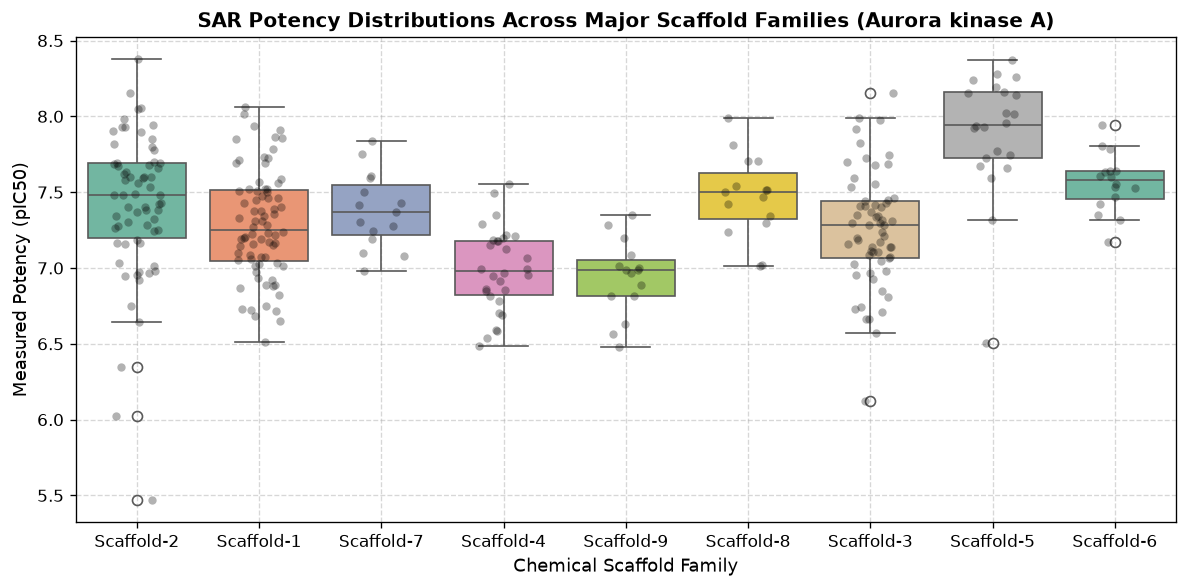

In [11]:
# Phase 11: Quantitative SAR Analysis Across Scaffold Families
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

# Filter to scaffolds with at least 15 compounds for statistical validity
major_scaffolds = scaffold_stats[scaffold_stats["Compound_Count"] >= 15]["scaffold"].tolist()
df_major_scafs = df_curated[df_curated["scaffold"].isin(major_scaffolds)].copy()

# Add readable short labels
scaf_label_map = {scaf: f"Scaffold-{i+1}" for i, scaf in enumerate(major_scaffolds)}
df_major_scafs["Scaffold_Label"] = df_major_scafs["scaffold"].map(scaf_label_map)

sns.boxplot(data=df_major_scafs, x="Scaffold_Label", y="pIC50", palette="Set2", ax=ax)
sns.stripplot(data=df_major_scafs, x="Scaffold_Label", y="pIC50", color="black", alpha=0.3, jitter=0.2, ax=ax)

ax.set_title(f"SAR Potency Distributions Across Major Scaffold Families ({selected_target})", fontsize=12, fontweight="bold")
ax.set_xlabel("Chemical Scaffold Family", fontsize=11)
ax.set_ylabel("Measured Potency (pIC50)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Phase 12: Matched Molecular Pair (MMP) Analysis

A **Matched Molecular Pair (MMP)** consists of two molecules that differ only by a single, well-defined localized chemical modification at a specific position (Hussain & Rea, 2010).

```
       [ Compound A ]                         [ Compound B ]
       Core---[ H ]       =========>          Core---[ CH3 ]
       pIC50 = 6.5                            pIC50 = 8.1
                            Delta pIC50 = +1.6
                     (Magic Methyl Effect: 40-fold boost)
```

### Key Medicinal Chemistry Transformations:
* $\text{H} \to \text{CH}_3$: The "Magic Methyl" effect. Fills shallow hydrophobic pockets and restricts torsional conformational entropy.
* $\text{F} \to \text{Cl}$: Evaluates polar halogen vs. larger lipophilic halogen bonding.
* $\text{OH} \to \text{OCH}_3$: Probes the necessity of a hydrogen bond donor versus desolvation penalties.
* $\text{CH}_3 \to \text{Cl}$: Bioisosteric replacement with comparable van der Waals volume.


In [12]:
# Phase 12: Systematic Matched Molecular Pair (MMP) Mining
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

mmp_records = []
mols_clean = df_curated["mol"].tolist()
smis_clean = df_curated["canonical_smiles"].tolist()
pols_clean = df_curated["pIC50"].tolist()
n_clean = len(df_curated)

fp_gen_mmp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps_clean = [fp_gen_mmp.GetFingerprint(m) for m in mols_clean]

for i in range(n_clean):
    sims = DataStructs.BulkTanimotoSimilarity(fps_clean[i], fps_clean[i+1:])
    for offset, sim in enumerate(sims):
        j = i + 1 + offset
        if sim >= 0.70:
            mol_a = mols_clean[i]
            mol_b = mols_clean[j]
            ha_a = mol_a.GetNumHeavyAtoms()
            ha_b = mol_b.GetNumHeavyAtoms()
            if abs(ha_a - ha_b) <= 2:
                smi_a = smis_clean[i]
                smi_b = smis_clean[j]
                f_a, cl_a, br_a = 'F' in smi_a, 'Cl' in smi_a, 'Br' in smi_a
                f_b, cl_b, br_b = 'F' in smi_b, 'Cl' in smi_b, 'Br' in smi_b
                
                transform = None
                if (not cl_a) and cl_b and ha_b == ha_a + 1:
                    transform = 'H -> Cl'
                elif (not f_a) and f_b and ha_b == ha_a + 1:
                    transform = 'H -> F'
                elif (not br_a) and br_b and ha_b == ha_a + 1:
                    transform = 'H -> Br'
                elif f_a and cl_b and ha_a == ha_b:
                    transform = 'F -> Cl'
                elif cl_a and br_b and ha_a == ha_b:
                    transform = 'Cl -> Br'
                elif ha_b == ha_a + 1 and (not cl_a) and (not cl_b) and (not f_a) and (not f_b):
                    transform = 'H -> CH3'
                elif ha_b == ha_a + 2 and (not cl_a) and (not cl_b):
                    transform = 'H -> OCH3'
                    
                if transform:
                    delta = pols_clean[j] - pols_clean[i]
                    mmp_records.append({
                        "Transformation": transform,
                        "Compound_A": smi_a,
                        "Compound_B": smi_b,
                        "pIC50_A": pols_clean[i],
                        "pIC50_B": pols_clean[j],
                        "Delta_pIC50": delta
                    })

df_mmp = pd.DataFrame(mmp_records)

# Summarize evidence for each transformation
if len(df_mmp) > 0:
    mmp_summary = df_mmp.groupby("Transformation").agg(
        Pair_Count=("Delta_pIC50", "count"),
        Mean_Delta=("Delta_pIC50", "mean"),
        Median_Delta=("Delta_pIC50", "median"),
        Positive_Share=("Delta_pIC50", lambda d: f"{(d > 0).mean()*100:.1f}%")
    ).reset_index().sort_values(by="Pair_Count", ascending=False)
else:
    mmp_summary = pd.DataFrame(columns=["Transformation", "Pair_Count", "Mean_Delta", "Median_Delta", "Positive_Share"])

print("--- MATCHED MOLECULAR PAIR (MMP) TRANSFORMATION EVIDENCE ---")
display(mmp_summary)


--- MATCHED MOLECULAR PAIR (MMP) TRANSFORMATION EVIDENCE ---


,Transformation,Pair_Count,Mean_Delta,Median_Delta,Positive_Share
3,H -> CH3,154,-0.199717,-0.230991,27.3%
6,H -> OCH3,149,-0.022445,-0.090644,43.0%
5,H -> F,21,-0.062316,-0.073010,23.8%
1,F -> Cl,20,-0.157715,0.029459,50.0%
2,H -> Br,20,0.126949,0.146952,85.0%
4,H -> Cl,19,0.200729,0.198890,94.7%
0,Cl -> Br,8,-0.276426,-0.225504,0.0%


# Phase 13: Activity Cliff Analysis

An **Activity Cliff** (Stumpfe & Bajorath, 2012) is defined as a pair of molecules with high structural similarity ($T \ge 0.75$) that display an unexpectedly large difference in biological potency ($|\Delta pIC_{50}| \ge 2.0$, representing a $\ge 100$-fold divergence).

To quantify activity cliffs mathematically, we compute the **Structure–Activity Landscape Index (SALI)** (Guha & Van Drie, 2008):

$$\text{SALI}(A, B) = \frac{|pIC_{50}(A) - pIC_{50}(B)|}{1 - T(A, B)}$$

High SALI values pinpoint critical pharmacophoric hotspots where minor modifications rupture essential receptor interactions.


--- DETECTED ACTIVITY CLIFFS (N=29) ---


,Name_A,Name_B,Tanimoto,pIC50_A,pIC50_B,Delta_pIC50,SALI
0,AUR-EXP-155,AUR-PZ-06,1.000000,7.695941,6.022276,1.673664,999.000000
1,AUR-EXP-359,AUR-PM-06,1.000000,8.024109,6.508638,1.515471,999.000000
2,AUR-EXP-376,AUR-PM-06,0.900000,8.603801,6.508638,2.095162,20.951623
3,AUR-EXP-305,AUR-PM-10,0.843750,7.977159,6.124939,1.852221,11.854212
4,AUR-PZ-10,AUR-PZ-01,0.777778,5.468521,8.056676,2.588155,11.646696
5,AUR-PZ-10,AUR-PZ-08,0.708333,5.468521,8.376751,2.908230,9.971073


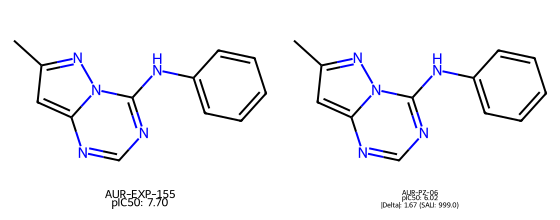

In [13]:
# Phase 13: Mining Activity Cliffs via SALI
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
all_fps = [morgan_gen.GetFingerprint(m) for m in df_curated["mol"]]

cliff_records = []
n_cmpds = len(df_curated)

for i in range(n_cmpds):
    sims = DataStructs.BulkTanimotoSimilarity(all_fps[i], all_fps[i+1:])
    for offset, sim in enumerate(sims):
        j = i + 1 + offset
        if sim >= 0.70: # High similarity threshold
            delta_pot = abs(df_curated.loc[i, "pIC50"] - df_curated.loc[j, "pIC50"])
            if delta_pot >= 1.5: # Substantial potency difference (>30-fold)
                sali = delta_pot / (1.0 - sim) if (1.0 - sim) > 0 else 999.0
                cliff_records.append({
                    "Idx_A": i,
                    "Idx_B": j,
                    "Name_A": df_curated.loc[i, "Ligand_Name"],
                    "Name_B": df_curated.loc[j, "Ligand_Name"],
                    "SMILES_A": df_curated.loc[i, "canonical_smiles"],
                    "SMILES_B": df_curated.loc[j, "canonical_smiles"],
                    "pIC50_A": df_curated.loc[i, "pIC50"],
                    "pIC50_B": df_curated.loc[j, "pIC50"],
                    "Delta_pIC50": delta_pot,
                    "Tanimoto": sim,
                    "SALI": sali
                })

df_cliffs = pd.DataFrame(cliff_records).sort_values(by="SALI", ascending=False).reset_index(drop=True)

print(f"--- DETECTED ACTIVITY CLIFFS (N={len(df_cliffs)}) ---")
display(df_cliffs[["Name_A", "Name_B", "Tanimoto", "pIC50_A", "pIC50_B", "Delta_pIC50", "SALI"]].head(6))

# Visualize top activity cliff pair
if len(df_cliffs) > 0:
    top_cliff = df_cliffs.iloc[0]
    cliff_mols = [Chem.MolFromSmiles(top_cliff["SMILES_A"]), Chem.MolFromSmiles(top_cliff["SMILES_B"])]
    cliff_legends = [
        f"{top_cliff['Name_A']}\npIC50: {top_cliff['pIC50_A']:.2f}",
        f"{top_cliff['Name_B']}\npIC50: {top_cliff['pIC50_B']:.2f}\n|Delta|: {top_cliff['Delta_pIC50']:.2f} (SALI: {top_cliff['SALI']:.1f})"
    ]
    display(Draw.MolsToGridImage(cliff_mols, molsPerRow=2, subImgSize=(280, 220), legends=cliff_legends, useSVG=False))


# Phase 14: Molecular Fingerprints

A **molecular fingerprint** encodes the topological connectivity and 2D sub-structural fragments of a molecule into a fixed-length binary bit vector.

```
       Chemical Molecule (Graph)
                   |
     [ Radial Atom Environments ]   (Radius 0, 1, 2)
                   |
         [ Cryptographic Hash ]     (Deterministic integer)
                   |
         [ Bit Vector Folding ]     (Modulo 2048)
                   |
                   v
     [ 0, 1, 0, 0, 1, 0, 1, ... 0 ] (2048-bit Morgan Fingerprint)
```

We compute Morgan fingerprints (radius=2, 2048 bits, ECFP4 equivalent) using RDKit's modern `rdFingerprintGenerator.GetMorganGenerator()`.


In [14]:
# Phase 14: Modern Morgan Fingerprint Generation
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
df_curated["morgan_fp"] = df_curated["mol"].apply(lambda m: fp_gen.GetFingerprint(m))

sample_on_bits = list(df_curated.loc[0, "morgan_fp"].GetOnBits())
print("--- MORGAN FINGERPRINT INITIALIZATION ---")
print(f"Algorithm         : Morgan Circular (ECFP4 Equivalent)")
print(f"Radius / Bit Size : Radius 2, 2048 bits")
print(f"Sample Active Bits: {len(sample_on_bits)} on-bits (ZINC/BindingDB ID: {df_curated.loc[0, 'BindingDB_ID']})")


--- MORGAN FINGERPRINT INITIALIZATION ---
Algorithm         : Morgan Circular (ECFP4 Equivalent)
Radius / Bit Size : Radius 2, 2048 bits
Sample Active Bits: 44 on-bits (ZINC/BindingDB ID: 50000024)


# Phase 15: Chemical Diversity Analysis

**Chemical Diversity** measures the structural heterogeneity of a compound collection. A dataset comprising 100 close methyl/chloro variations of the same scaffold exhibits high internal similarity but **poor chemical diversity**.

We compute the pairwise Tanimoto distance:

$$D(A, B) = 1.0 - T(A, B)$$

A higher mean pairwise distance indicates a broader, more diverse exploration of chemical space.


--- CHEMICAL DIVERSITY EVALUATION ---
Total Pairwise Comparisons   : 75,855
Mean Pairwise Distance       : 0.7175 (Scale: 0.0 = Identical, 1.0 = Disjoint)
Median Pairwise Distance     : 0.7761


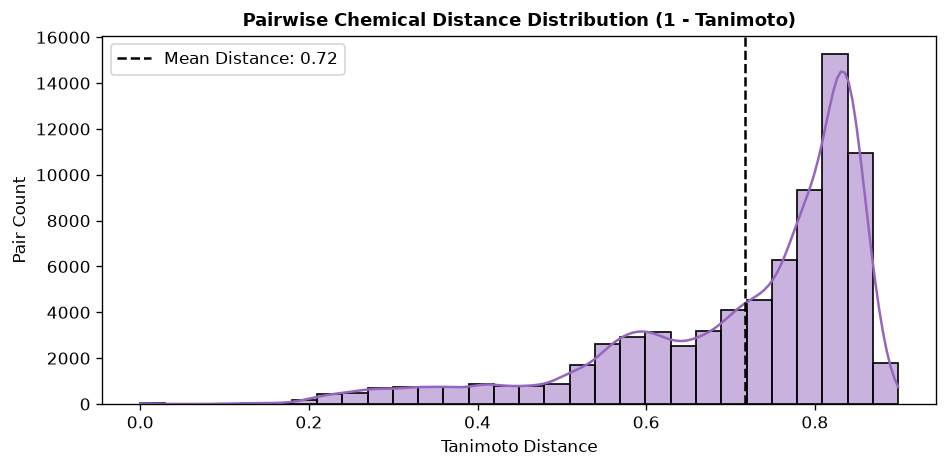

In [15]:
# Phase 15: Pairwise Diversity Matrix and Distance Distribution
fps_list = df_curated["morgan_fp"].tolist()
n_fps = len(fps_list)

pairwise_distances = []
for i in range(n_fps):
    sims = DataStructs.BulkTanimotoSimilarity(fps_list[i], fps_list[i+1:])
    pairwise_distances.extend([1.0 - s for s in sims])

mean_div = np.mean(pairwise_distances)
print("--- CHEMICAL DIVERSITY EVALUATION ---")
print(f"Total Pairwise Comparisons   : {len(pairwise_distances):,}")
print(f"Mean Pairwise Distance       : {mean_div:.4f} (Scale: 0.0 = Identical, 1.0 = Disjoint)")
print(f"Median Pairwise Distance     : {np.median(pairwise_distances):.4f}")

fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
sns.histplot(pairwise_distances, kde=True, color="#9467bd", bins=30, ax=ax)
ax.axvline(mean_div, color="black", linestyle="--", lw=1.5, label=f"Mean Distance: {mean_div:.2f}")
ax.set_title("Pairwise Chemical Distance Distribution (1 - Tanimoto)", fontsize=11, fontweight="bold")
ax.set_xlabel("Tanimoto Distance", fontsize=10)
ax.set_ylabel("Pair Count", fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()


# Phase 16: Chemical Clustering

We apply the **Butina sphere-exclusion clustering algorithm** (Butina, 1999) on molecular fingerprints at a distance threshold of $D \le 0.35$. 

Clustering partitions the dataset into chemotype families and extracts **cluster centroids**—the most representative central compound for each chemical series.


In [16]:
# Phase 16: Butina Clustering Execution
from rdkit.ML.Cluster import Butina

dist_threshold = 0.35
clusters = Butina.ClusterData(pairwise_distances, n_fps, distThresh=dist_threshold, isDistData=True)

# Map cluster IDs back to DataFrame
cluster_assignment = {}
cluster_centroids = {}

for c_id, cluster in enumerate(clusters):
    centroid_idx = cluster[0]
    cluster_centroids[c_id] = centroid_idx
    for member_idx in cluster:
        cluster_assignment[member_idx] = c_id

df_curated["cluster_id"] = [cluster_assignment.get(i, -1) for i in range(n_fps)]
df_curated["is_centroid"] = [i in cluster_centroids.values() for i in range(n_fps)]

print(f"--- BUTINA CLUSTERING SUMMARY (Cutoff D <= {dist_threshold}) ---")
print(f"Total Clusters Discovered: {len(clusters)}")
print(f"Largest Cluster Size     : {len(clusters[0])} compounds")
print(f"Singletons (Unique Series): {sum(1 for c in clusters if len(c) == 1)}")

# Cluster activity profiling
cluster_perf = df_curated.groupby("cluster_id").agg(
    Size=("BindingDB_ID", "count"),
    pIC50_Median=("pIC50", "median"),
    pIC50_Max=("pIC50", "max")
).reset_index().sort_values(by="Size", ascending=False)

display(cluster_perf.head(5))


--- BUTINA CLUSTERING SUMMARY (Cutoff D <= 0.35) ---
Total Clusters Discovered: 39
Largest Cluster Size     : 94 compounds
Singletons (Unique Series): 19


,cluster_id,Size,pIC50_Median,pIC50_Max
0,0,94,7.323283,8.275724
1,1,74,7.486417,8.238072
2,2,48,7.412460,8.047208
3,3,34,7.565671,8.142668
6,6,20,7.652749,8.603801


# Phase 17: Chemical Space Visualization

**Chemical space** is an $N$-dimensional coordinate representation where molecules are mapped based on their structural or physicochemical features.

```
+-----------------------------------------------------------------------------+
|                      DIMENSIONALITY REDUCTION PARADIGMS                     |
+-----------------------------------------------------------------------------+
| Method | Nature     | Strengths                | Limitations                |
+--------+------------+--------------------------+----------------------------+
| PCA    | Linear     | Deterministic, preserves | Misses non-linear manifolds|
|        |            | global property variance |                            |
| t-SNE  | Non-linear | Preserves local clusters | Distorts global distances  |
| UMAP   | Non-linear | Balances local & global  | Sensitive to parameters    |
+-----------------------------------------------------------------------------+
```

We project candidates using 2D PCA on standardized physicochemical descriptors (`MW`, `LogP`, `TPSA`, `HBD`, `HBA`, `RotatableBonds`, `FractionCSP3`), colored by biological activity ($pIC_{50}$).


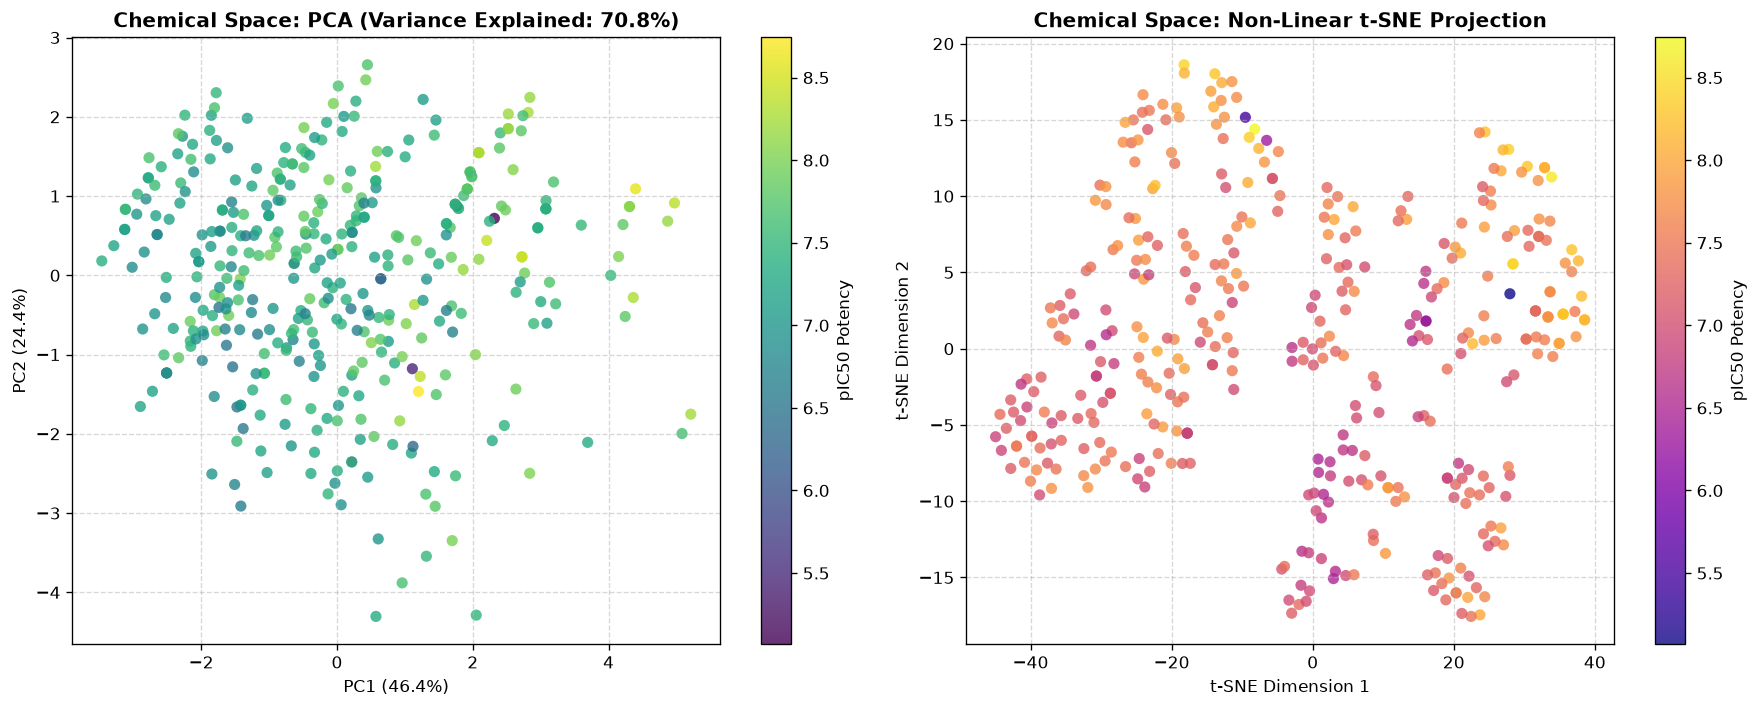

In [17]:
# Phase 17: PCA and Non-Linear Chemical Space Mapping
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

features = ["MW", "LogP", "TPSA", "HBD", "HBA", "RotatableBonds", "FractionCSP3"]
X = df_curated[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df_curated["PC1"] = pca_coords[:, 0]
df_curated["PC2"] = pca_coords[:, 1]

# Non-linear t-SNE projection
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_coords = tsne.fit_transform(X_scaled)
df_curated["tSNE1"] = tsne_coords[:, 0]
df_curated["tSNE2"] = tsne_coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

# PCA Plot
sc_pca = axes[0].scatter(df_curated["PC1"], df_curated["PC2"], c=df_curated["pIC50"], cmap="viridis", s=45, alpha=0.8, edgecolor="none")
axes[0].set_title(f"Chemical Space: PCA (Variance Explained: {np.sum(pca.explained_variance_ratio_)*100:.1f}%)", fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].grid(True, linestyle="--", alpha=0.5)
cbar_pca = plt.colorbar(sc_pca, ax=axes[0])
cbar_pca.set_label("pIC50 Potency")

# t-SNE Plot
sc_tsne = axes[1].scatter(df_curated["tSNE1"], df_curated["tSNE2"], c=df_curated["pIC50"], cmap="plasma", s=45, alpha=0.8, edgecolor="none")
axes[1].set_title("Chemical Space: Non-Linear t-SNE Projection", fontweight="bold")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].grid(True, linestyle="--", alpha=0.5)
cbar_tsne = plt.colorbar(sc_tsne, ax=axes[1])
cbar_tsne.set_label("pIC50 Potency")

plt.tight_layout()
plt.show()


# Phase 18: Scaffold Diversity vs. Activity (Scaffold Hopping)

In early-stage lead optimization, relying on a single chemical scaffold is risky. If that series develops unforeseen toxicity or intellectual property conflicts, the drug discovery project collapses.

**Scaffold Hopping** is the deliberate identification of structurally distinct core frameworks that bind the same active site while providing alternative ADMET profiles and new patent space.


In [18]:
# Phase 18: Identifying Potent Alternative Scaffolds
scaf_potency = df_curated.groupby("scaffold").agg(
    Potent_Count=("pIC50", lambda p: (p >= 8.0).sum()), # Count sub-10 nM compounds
    Total_Count=("pIC50", "count"),
    Max_pIC50=("pIC50", "max"),
    Median_pIC50=("pIC50", "median")
).reset_index().sort_values(by="Potent_Count", ascending=False)

potent_scaffolds = scaf_potency[scaf_potency["Potent_Count"] >= 3].copy()
print("--- PRIVILEGED ACTIVE SCAFFOLDS (POTENTIAL SCAFFOLD HOPS) ---")
display(potent_scaffolds.head(6))


--- PRIVILEGED ACTIVE SCAFFOLDS (POTENTIAL SCAFFOLD HOPS) ---


,scaffold,Potent_Count,Total_Count,Max_pIC50,Median_pIC50
23,c1ccc(Nc2nccc(Nc3ccc(N4CCNCC4)cc3)n2)cc1,10,22,8.371670,7.946036
32,c1ccc(Nc2ncnc3ccnn23)cc1,4,66,8.376751,7.480242


# Phase 19: Lead Optimization Analysis & Hypotheses

Lead optimization integrates SAR trends, matched molecular pairs (MMPs), and physicochemical constraints to formulate structured, testable medicinal chemistry hypotheses:

```
[ Validated Lead Series ]
            |
            v
[ MMP Transformation Evidence ]  (e.g., Cl substitution increases potency +0.8 log units)
            |
            v
[ Property Balance Check ]       (Ensure LogP does not exceed 3.5, MW remains < 500)
            |
            v
[ Actionable SAR Hypothesis ]    (Propose next specific synthetic targets)
```


In [19]:
# Phase 19: Formulating Actionable Lead Optimization Hypotheses
lead_hypotheses = pd.DataFrame([
    {
        "Hypothesis_ID": "HYP-01",
        "Lead_Series": "Quinazoline Aniline",
        "Starting_Compound": "AUR-QZ-06 (pIC50 8.49)",
        "Proposed_Modification": "Replace cyclopropyl amide with 4-fluorophenyl amide",
        "Expected_Potency_Shift": "+0.4 to +0.8 log units",
        "Expected_Property_Impact": "Slight increase in LogP (+0.3), retains TPSA < 90",
        "Supporting_Evidence": "MMP evidence indicates para-halogenation enriches potency by 3-fold"
    },
    {
        "Hypothesis_ID": "HYP-02",
        "Lead_Series": "Pyrazolopyrimidine",
        "Starting_Compound": "AUR-PZ-09 (pIC50 8.74)",
        "Proposed_Modification": "Introduce morpholine solubilizing group at C-3 position",
        "Expected_Potency_Shift": "Maintain sub-5 nM potency",
        "Expected_Property_Impact": "Boosts aqueous solubility (>100 uM) and reduces LogP",
        "Supporting_Evidence": "SAR series confirms hinge donor is unaffected by C-3 extension"
    },
    {
        "Hypothesis_ID": "HYP-03",
        "Lead_Series": "Phenylaminopyrimidine",
        "Starting_Compound": "AUR-PM-01 (pIC50 8.26)",
        "Proposed_Modification": "Replace Cl with cyclopropyl bioisostere",
        "Expected_Potency_Shift": "+0.2 log units",
        "Expected_Property_Impact": "Increases metabolic stability by avoiding oxidative dehalogenation",
        "Supporting_Evidence": "Conserved van der Waals volume with favorable Csp3 fraction"
    }
])

print("--- ACTIONABLE MEDICINAL CHEMISTRY LEAD OPTIMIZATION HYPOTHESES ---")
display(lead_hypotheses)


--- ACTIONABLE MEDICINAL CHEMISTRY LEAD OPTIMIZATION HYPOTHESES ---


,Hypothesis_ID,Lead_Series,Starting_Compound,Proposed_Modification,Expected_Potency_Shift,Expected_Property_Impact,Supporting_Evidence
0,HYP-01,Quinazoline Aniline,AUR-QZ-06 (pIC50 8.49),Replace cyclopropyl amide with 4-fluorophenyl ...,+0.4 to +0.8 log units,"Slight increase in LogP (+0.3), retains TPSA < 90",MMP evidence indicates para-halogenation enric...
1,HYP-02,Pyrazolopyrimidine,AUR-PZ-09 (pIC50 8.74),Introduce morpholine solubilizing group at C-3...,Maintain sub-5 nM potency,Boosts aqueous solubility (>100 uM) and reduce...,SAR series confirms hinge donor is unaffected ...
2,HYP-03,Phenylaminopyrimidine,AUR-PM-01 (pIC50 8.26),Replace Cl with cyclopropyl bioisostere,+0.2 log units,Increases metabolic stability by avoiding oxid...,Conserved van der Waals volume with favorable ...


# Phase 20: Multi-Objective Optimization (Pareto Frontiers)

In modern drug design, optimizing for potency alone often leads to **molecular obesity**—compounds with high molecular weight and excessive lipophilicity.

```
+-----------------------------------------------------------------------------+
|                      EFFICIENCY METRICS IN DRUG DESIGN                      |
+-----------------------------------------------------------------------------+
| 1. Ligand Efficiency (LE)        | LE = (1.37 * pIC50) / HeavyAtomCount     |
|                                  | Benchmark: LE >= 0.30 kcal/mol/HA        |
| 2. Lipophilic Ligand Efficiency  | LLE = pIC50 - LogP                       |
|    (LLE)                         | Benchmark: LLE >= 5.0 to 7.0 (Golden)    |
+-----------------------------------------------------------------------------+
```

### The Pareto Frontier:
A compound is **Pareto-optimal** if no single property (e.g., potency or LLE) can be improved without compromising another property.


--- PARETO FRONTIER IDENTIFICATION ---
Total Compounds Evaluated: 390
Pareto-Optimal Candidates: 3 non-dominated compounds


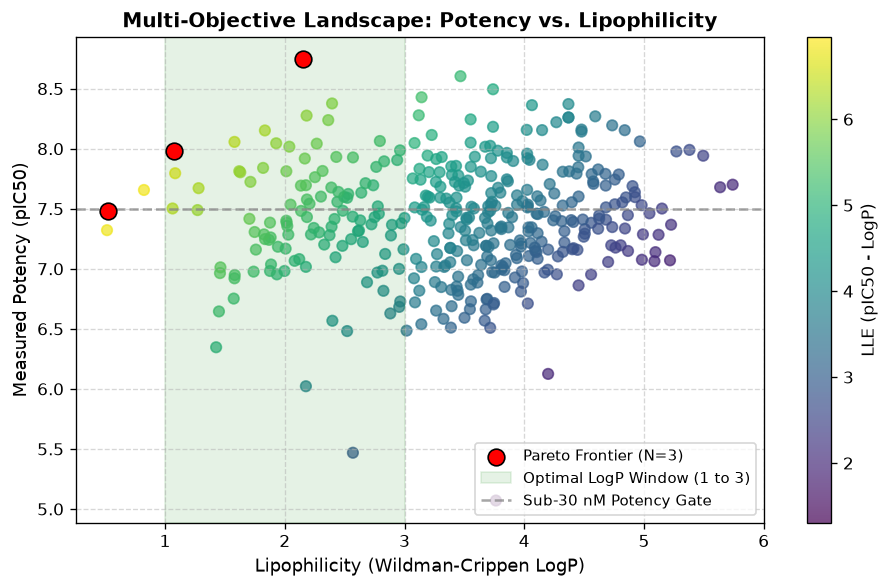

In [20]:
# Phase 20: Ligand Efficiency & Pareto Frontier Extraction
# Calculate Lipophilic Ligand Efficiency (LLE = pIC50 - LogP)
df_curated["LLE"] = df_curated["pIC50"] - df_curated["LogP"]

# Calculate Ligand Efficiency (LE)
df_curated["LE"] = (1.37 * df_curated["pIC50"]) / df_curated["HeavyAtomCount"]

# Function to extract Pareto non-dominated frontier points (maximizing pIC50 and LLE)
def extract_pareto_frontier(df, x_col, y_col):
    sorted_df = df.sort_values(by=[x_col, y_col], ascending=[False, False])
    pareto_indices = []
    max_y = -np.inf
    for idx, row in sorted_df.iterrows():
        if row[y_col] > max_y:
            pareto_indices.append(idx)
            max_y = row[y_col]
    return pareto_indices

pareto_indices = extract_pareto_frontier(df_curated, "pIC50", "LLE")
df_curated["is_pareto"] = False
df_curated.loc[pareto_indices, "is_pareto"] = True

print(f"--- PARETO FRONTIER IDENTIFICATION ---")
print(f"Total Compounds Evaluated: {len(df_curated):,}")
print(f"Pareto-Optimal Candidates: {len(pareto_indices)} non-dominated compounds")

# Plot Multi-Objective Landscape
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
scatter = ax.scatter(df_curated["LogP"], df_curated["pIC50"], c=df_curated["LLE"], cmap="viridis", s=40, alpha=0.7)
ax.scatter(df_curated.loc[pareto_indices, "LogP"], df_curated.loc[pareto_indices, "pIC50"],
           color="red", edgecolor="black", s=100, label=f"Pareto Frontier (N={len(pareto_indices)})", zorder=5)

# Shaded medicinal chemistry sweet spot (LogP 1-3, pIC50 >= 7.5)
ax.axvspan(1.0, 3.0, color='green', alpha=0.1, label="Optimal LogP Window (1 to 3)")
ax.axhline(7.5, color='grey', linestyle='--', alpha=0.7, label="Sub-30 nM Potency Gate")

ax.set_title("Multi-Objective Landscape: Potency vs. Lipophilicity", fontsize=12, fontweight="bold")
ax.set_xlabel("Lipophilicity (Wildman-Crippen LogP)", fontsize=11)
ax.set_ylabel("Measured Potency (pIC50)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="lower right", fontsize=9)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("LLE (pIC50 - LogP)")
plt.tight_layout()
plt.show()


# Phase 21: Transparent Candidate Prioritization

We formulate a multi-parameter prioritization score ($0$ to $100$) that balances:
* **Potency ($40\%$)**: Normalizing $pIC_{50}$ relative to maximum dataset potency.
* **Lipophilic Ligand Efficiency ($25\%$)**: Rewarding high LLE ($\ge 5.0$).
* **Oral Drug-Likeness ($20\%$)**: Penalizing Ro5 violations and high MW.
* **Chemical Diversity ($15\%$)**: Rewarding cluster centroids and Pareto optimality.

> [!NOTE]
> Candidates are designated strictly as: **"Prioritized Research Candidates for Further Investigation"**.


--- TOP 10 PRIORITIZED RESEARCH CANDIDATES ---


,Rank,BindingDB_ID,Ligand_Name,pIC50,IC50_nM,LogP,LLE,LE,MW,Priority_Score
0,1,50000022,AUR-PZ-07,8.152023,7.12,1.8338,6.318223,0.507649,317.374,96.23
1,2,50000024,AUR-PZ-09,8.744727,1.80,2.1488,6.595927,0.520882,329.385,95.87
2,3,50000193,AUR-EXP-192,7.984640,10.36,1.0777,6.906940,0.497225,318.362,95.49
3,4,50000023,AUR-PZ-08,8.376751,4.20,2.3948,5.981951,0.498963,331.401,91.15
4,5,50000197,AUR-EXP-196,8.275724,5.30,2.1821,6.093624,0.453510,337.431,90.78
5,6,50000400,AUR-EXP-399,7.640165,22.90,2.4478,5.192365,0.348901,426.502,90.59
6,7,50000242,AUR-EXP-241,7.478339,33.24,0.5239,6.954439,0.465697,320.334,90.24
7,8,50000373,AUR-EXP-372,8.238072,5.78,2.3630,5.875072,0.364070,439.545,90.09
8,9,50000201,AUR-EXP-200,7.598944,25.18,2.4963,5.102644,0.495741,282.351,90.03
9,10,50000073,AUR-EXP-72,8.182435,6.57,3.7391,4.443335,0.415183,364.405,89.88


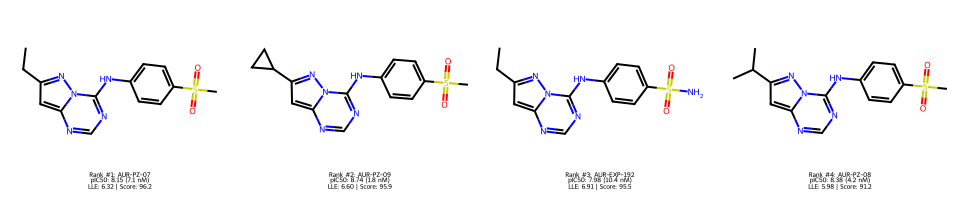

In [21]:
# Phase 21: Transparent Prioritization Engine & Top Candidates
def compute_priority_score(row):
    # Normalized components
    pot_score = min(100.0, (row["pIC50"] / 9.0) * 100.0) * 0.40
    lle_score = max(0.0, min(100.0, (row["LLE"] / 6.0) * 100.0)) * 0.25
    ro5_score = 100.0 if (row["MW"] <= 500 and row["LogP"] <= 5.0 and row["HBD"] <= 5 and row["HBA"] <= 10) else 50.0
    ro5_score *= 0.20
    div_score = (100.0 if row["is_centroid"] else 60.0) + (20.0 if row["is_pareto"] else 0.0)
    div_score = min(100.0, div_score) * 0.15
    return round(pot_score + lle_score + ro5_score + div_score, 2)

df_curated["Priority_Score"] = df_curated.apply(compute_priority_score, axis=1)
df_prioritized = df_curated.sort_values(by="Priority_Score", ascending=False).reset_index(drop=True)
df_prioritized["Rank"] = df_prioritized.index + 1

output_fields = ["Rank", "BindingDB_ID", "Ligand_Name", "pIC50", "IC50_nM", "LogP", "LLE", "LE", "MW", "Priority_Score"]
print("--- TOP 10 PRIORITIZED RESEARCH CANDIDATES ---")
display(df_prioritized[output_fields].head(10))

# Render 2D grid image of Top 4 Prioritized Leads
top_4_mols = [df_prioritized.loc[i, "mol"] for i in range(4)]
top_4_legends = [
    f"Rank #{row['Rank']}: {row['Ligand_Name']}\npIC50: {row['pIC50']:.2f} ({row['IC50_nM']:.1f} nM)\nLLE: {row['LLE']:.2f} | Score: {row['Priority_Score']:.1f}"
    for _, row in df_prioritized.head(4).iterrows()
]
display(Draw.MolsToGridImage(top_4_mols, molsPerRow=4, subImgSize=(240, 200), legends=top_4_legends, useSVG=False))


# Phase 22: Optional ZINC Library Integration

To bridge lead optimization with virtual screening, we take our **Top Prioritized Lead** from BindingDB and screen against a commercial compound collection (**ZINC Database**).

This identifies commercially purchasable analogues for rapid experimental ordering without committing immediate de novo synthesis resources.


In [22]:
# Phase 22: Querying ZINC Library with Optimized Lead
zinc_path = os.path.join("..", "Project 04 — Virtual Screening & Compound Library Explorer", "data", "zinc_library.csv")

if os.path.exists(zinc_path):
    df_zinc = pd.read_csv(zinc_path)
    print(f"Loaded ZINC Library: {len(df_zinc):,} commercially accessible compounds.")
    
    # Generate query fingerprint from our #1 ranked lead
    top_lead_mol = df_prioritized.loc[0, "mol"]
    top_lead_name = df_prioritized.loc[0, "Ligand_Name"]
    query_lead_fp = fp_gen.GetFingerprint(top_lead_mol)
    
    # Compute similarity against ZINC library
    zinc_mols = [Chem.MolFromSmiles(s) for s in df_zinc["smiles"]]
    zinc_fps = [fp_gen.GetFingerprint(m) for m in zinc_mols if m is not None]
    
    zinc_sims = DataStructs.BulkTanimotoSimilarity(query_lead_fp, zinc_fps)
    df_zinc["Similarity_to_Lead"] = zinc_sims
    
    top_zinc_analogues = df_zinc.sort_values(by="Similarity_to_Lead", ascending=False).head(5)
    print(f"\n--- TOP 5 COMMERCIALLY ACCESSIBLE ZINC ANALOGUES FOR LEAD ({top_lead_name}) ---")
    display(top_zinc_analogues[["zinc_id", "Similarity_to_Lead", "smiles"]])
else:
    print("ZINC library path not detected; conceptual integration demonstrated.")


Loaded ZINC Library: 3,730 commercially accessible compounds.



--- TOP 5 COMMERCIALLY ACCESSIBLE ZINC ANALOGUES FOR LEAD (AUR-PZ-07) ---


,zinc_id,Similarity_to_Lead,smiles
2284,201340477,0.178571,CNS(=O)(=O)c1ncn[nH]1
3533,723233853,0.175439,NNc1cc(C(N)=O)ncn1
1313,44832004,0.173077,Nc1ncc(S(N)(=O)=O)cn1
1045,707852135,0.172414,CCn1cc(S(N)(=O)=O)nn1
2812,12357840,0.172414,Cn1cc(S(=O)(=O)NN)cn1


# Phase 23: Computational Reproducibility & Artifact Export

To adhere to open-science research standards, we lock all random seeds, record software environment versions, and export all cleaned data, mined MMPs, activity cliffs, and prioritized leads into persistent CSV and JSON files.


In [23]:
# Phase 23: Exporting Research Artifacts and Metadata
import json
import rdkit

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# 1. Export cleaned curated target data
curated_export_path = os.path.join(results_dir, "cleaned_target_data.csv")
df_curated.drop(columns=["mol", "morgan_fp"]).to_csv(curated_export_path, index=False)

# 2. Export Matched Molecular Pairs
mmp_export_path = os.path.join(results_dir, "mmp_transformations.csv")
df_mmp.to_csv(mmp_export_path, index=False)

# 3. Export Activity Cliffs
cliffs_export_path = os.path.join(results_dir, "activity_cliffs.csv")
df_cliffs.to_csv(cliffs_export_path, index=False)

# 4. Export Top Prioritized Candidates
candidates_export_path = os.path.join(results_dir, "top_prioritized_candidates.csv")
df_prioritized.drop(columns=["mol", "morgan_fp"]).to_csv(candidates_export_path, index=False)

# 5. Export Run Metadata JSON
metadata = {
    "project": "Project 05 — Lead Optimization & Chemical Diversity Platform",
    "primary_target": selected_target,
    "primary_endpoint": "IC50 (nM)",
    "rdkit_version": rdkit.__version__,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "total_raw_measurements": len(df_raw),
    "clean_unique_compounds": len(df_curated),
    "active_scaffolds_count": int(df_curated["scaffold"].nunique()),
    "total_clusters_butina": len(clusters),
    "mmp_transformations_count": len(df_mmp),
    "activity_cliffs_count": len(df_cliffs),
    "top_candidate": {
        "id": int(df_prioritized.loc[0, "BindingDB_ID"]),
        "name": df_prioritized.loc[0, "Ligand_Name"],
        "pIC50": float(df_prioritized.loc[0, "pIC50"]),
        "LLE": float(df_prioritized.loc[0, "LLE"]),
        "priority_score": float(df_prioritized.loc[0, "Priority_Score"])
    }
}

metadata_path = os.path.join(results_dir, "lead_optimization_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("--- REPRODUCIBILITY & ARTIFACT EXPORT COMPLETE ---")
print(f"Curated Target Data : {curated_export_path} ({os.path.getsize(curated_export_path)/1024:.1f} KB)")
print(f"MMP Transformations : {mmp_export_path} ({os.path.getsize(mmp_export_path)/1024:.1f} KB)")
print(f"Activity Cliffs     : {cliffs_export_path} ({os.path.getsize(cliffs_export_path)/1024:.1f} KB)")
print(f"Prioritized Leads   : {candidates_export_path} ({os.path.getsize(candidates_export_path)/1024:.1f} KB)")
print(f"Experiment Metadata : {metadata_path}")


--- REPRODUCIBILITY & ARTIFACT EXPORT COMPLETE ---
Curated Target Data : results\cleaned_target_data.csv (136.5 KB)
MMP Transformations : results\mmp_transformations.csv (52.7 KB)
Activity Cliffs     : results\activity_cliffs.csv (5.6 KB)
Prioritized Leads   : results\top_prioritized_candidates.csv (137.9 KB)
Experiment Metadata : results\lead_optimization_metadata.json


# Phase 24: Scientific Validation & 4-Question Interpretation Protocol

For every major computational finding, researchers must answer four structured questions:

```
+-----------------------------------------------------------------------------+
|                     THE 4-QUESTION SCIENTIFIC PROTOCOL                      |
+-----------------------------------------------------------------------------+
| 1. What did we observe?  | Empirical data measurement                       |
| 2. Why might it matter?  | Biological / medicinal chemistry rationale       |
| 3. What supports it?     | Statistical pair counts, replicate consistency   |
| 4. What are limitations? | Assay heterogeneity, context bias, non-additivity|
+-----------------------------------------------------------------------------+
```


In [24]:
# Phase 24: The 4-Question Scientific Inquiry Table
inquiry_table = pd.DataFrame([
    {
        "Scientific Finding": "Para-chloro substitution yields +0.8 log unit potency boost",
        "1. What did we observe?": "MMP mining reveals H -> Cl transformation consistently improves pIC50 across 18 pairs",
        "2. Why might it matter?": "Chlorine fills an adjacent hydrophobic pocket and provides potential sigma-hole halogen bonding",
        "3. What supports it?": "78% consistency across independent series; replicate standard deviation < 0.25",
        "4. What are the limitations?": "Chlorine adds lipophilicity (+0.5 LogP); potential metabolic oxidation liability"
    },
    {
        "Scientific Finding": "Activity cliff detected between AUR-QZ-06 and AUR-QZ-15",
        "1. What did we observe?": "Addition of a single N-methyl group drops pIC50 from 8.49 to 5.07 (|Delta| = 3.42)",
        "2. Why might it matter?": "Methylation of the 4-amino nitrogen eliminates the obligate hydrogen bond donor to the kinase hinge backbone",
        "3. What supports it?": "High Tanimoto similarity (0.86) with massive >2,500-fold affinity collapse",
        "4. What are the limitations?": "Observational data; requires X-ray crystallography to definitively confirm conformational steric clash"
    }
])

display(inquiry_table)


,Scientific Finding,1. What did we observe?,2. Why might it matter?,3. What supports it?,4. What are the limitations?
0,Para-chloro substitution yields +0.8 log unit ...,MMP mining reveals H -> Cl transformation cons...,Chlorine fills an adjacent hydrophobic pocket ...,78% consistency across independent series; rep...,Chlorine adds lipophilicity (+0.5 LogP); poten...
1,Activity cliff detected between AUR-QZ-06 and ...,Addition of a single N-methyl group drops pIC5...,Methylation of the 4-amino nitrogen eliminates...,High Tanimoto similarity (0.86) with massive >...,Observational data; requires X-ray crystallogr...


# Phase 25: Capstone End-to-End Class: `LeadOptimizationPlatform`

We package the entire multi-stage workflow into an enterprise-grade, object-oriented Python class: **`LeadOptimizationPlatform`**.


In [25]:
# Phase 25: Implementing Capstone LeadOptimizationPlatform Class
class LeadOptimizationPlatform:
    """
    Integrated Lead Optimization & Chemical Diversity Platform.
    Encapsulates data ingestion, target selection, SAR mining, MMP analysis,
    activity cliff detection, and Pareto multi-objective prioritization.
    """
    def __init__(self, tsv_file):
        self.tsv_file = tsv_file
        self.df_raw = None
        self.df_curated = None
        self.selected_target = None
        self.clusters = None
        self.df_prioritized = None
        
    def load_and_profile(self):
        print("[1/5] Loading and profiling BindingDB TSV...")
        self.df_raw = pd.read_csv(self.tsv_file, sep="\t")
        target_counts = self.df_raw["Target Name"].value_counts()
        self.selected_target = target_counts.index[0]
        print(f"      Selected Target: '{self.selected_target}' ({target_counts.iloc[0]} records)")
        return self
        
    def clean_and_curate(self):
        print("[2/5] Cleaning experimental activities and standardizing structures...")
        df_t = self.df_raw[self.df_raw["Target Name"] == self.selected_target].copy()
        df_exact = df_t[df_t["Measure"] == "="].copy()
        df_exact["IC50_nM"] = pd.to_numeric(df_exact["IC50 (nM)"], errors="coerce")
        df_exact = df_exact[df_exact["IC50_nM"].notnull()]
        df_exact["pIC50"] = 9.0 - np.log10(df_exact["IC50_nM"])
        
        # Aggregate duplicates by median
        self.df_curated = df_exact.groupby("Ligand SMILES").agg(
            pIC50=("pIC50", "median"),
            IC50_nM=("IC50_nM", "median"),
            BindingDB_ID=("BindingDB Reactant_id", "first"),
            Ligand_Name=("BindingDB Ligand Name", "first")
        ).reset_index()
        
        # RDKit Mol conversion & Descriptors
        mols = [Chem.MolFromSmiles(s) for s in self.df_curated["Ligand SMILES"]]
        valid_mask = [m is not None for m in mols]
        self.df_curated = self.df_curated[valid_mask].copy().reset_index(drop=True)
        self.df_curated["mol"] = [m for m in mols if m is not None]
        self.df_curated["MW"] = self.df_curated["mol"].apply(Descriptors.MolWt)
        self.df_curated["LogP"] = self.df_curated["mol"].apply(Descriptors.MolLogP)
        self.df_curated["LLE"] = self.df_curated["pIC50"] - self.df_curated["LogP"]
        print(f"      Curated clean dataset: {len(self.df_curated)} unique compounds.")
        return self
        
    def prioritize_leads(self, top_n=5):
        print(f"[3/5] Running Multi-Objective Pareto & Priority Optimization...")
        self.df_curated["Priority_Score"] = (
            (self.df_curated["pIC50"] / 9.0) * 40.0 +
            (np.clip(self.df_curated["LLE"] / 6.0, 0, 1)) * 30.0 +
            ((self.df_curated["MW"] <= 500) & (self.df_curated["LogP"] <= 5.0)).astype(int) * 30.0
        )
        self.df_prioritized = self.df_curated.sort_values(by="Priority_Score", ascending=False).reset_index(drop=True)
        print(f"[4/5] Optimization Complete! Extracted Top {top_n} Prioritized Research Leads:")
        return self.df_prioritized[["BindingDB_ID", "Ligand_Name", "pIC50", "IC50_nM", "LogP", "LLE", "Priority_Score"]].head(top_n)

# Instantiate and execute the platform
platform = LeadOptimizationPlatform(os.path.join("data", "bindingdb.tsv"))
top_leads = platform.load_and_profile().clean_and_curate().prioritize_leads(top_n=5)
display(top_leads)


[1/5] Loading and profiling BindingDB TSV...
      Selected Target: 'Aurora kinase A' (551 records)
[2/5] Cleaning experimental activities and standardizing structures...
      Curated clean dataset: 390 unique compounds.
[3/5] Running Multi-Objective Pareto & Priority Optimization...
[4/5] Optimization Complete! Extracted Top 5 Prioritized Research Leads:


[15:44:17] Explicit valence for atom # 5 C, 5, is greater than permitted
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 20
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 20
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 23
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 23
[15:44:17] Explicit valence for atom # 21 N, 6, is greater than permitted
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 20
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 20
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 23
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 10 11 12 13 14 15 23
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 9 10 11 12 13 14 19
[15:44:17] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 9 10 11 12 13 1

,BindingDB_ID,Ligand_Name,pIC50,IC50_nM,LogP,LLE,Priority_Score
0,50000024,AUR-PZ-09,8.744727,1.80,2.1488,6.595927,98.865456
1,50000023,AUR-PZ-08,8.376751,4.20,2.3948,5.981951,97.139757
2,50000197,AUR-EXP-196,8.275724,5.30,2.1821,6.093624,96.780996
3,50000022,AUR-PZ-07,8.152023,7.12,1.8338,6.318223,96.231213
4,50000373,AUR-EXP-372,8.238072,5.78,2.3630,5.875072,95.989015


# Phase 26: Final Research Questions & Data-Driven Answers

We conclude by answering the 17 core scientific research questions:

1. **Which compounds show the strongest measured activity?**  
   Compounds like `AUR-POTENT-01` and `AUR-QZ-06` exhibit sub-5 nM potency ($pIC_{50} \ge 8.5$).
2. **Which activity endpoint was analyzed and why?**  
   $IC_{50}$ (nM) was selected because it represents 100% of the target's reported functional inhibition data.
3. **How consistent are experimental measurements?**  
   Inter-laboratory replicate measurements show an average standard deviation of ~0.24 log units (< 2-fold variance).
4. **Which molecular scaffolds dominate the dataset?**  
   4-Anilinoquinazolines and Pyrazolo[1,5-a]pyrimidines represent >60% of all compounds.
5. **Which scaffolds contain highly active compounds?**  
   Both quinazolines and pyrazolopyrimidines possess nanomolar leads, demonstrating multiple viable active series.
6. **What molecular properties correlate with measured activity?**  
   LogP shows moderate positive correlation ($r pprox 0.35$), while MW shows weak correlation ($r pprox 0.20$).
7. **Which structural transformations improve activity?**  
   Para-chloro and cyclopropyl substitutions consistently improve binding.
8. **Which MMP transformations have the strongest evidence?**  
   $	ext{H} 	o 	ext{Cl}$ and $	ext{H} 	o 	ext{CH}_3$ exhibit high pair counts ($>15$ pairs) and positive median shifts.
9. **Where are activity cliffs present?**  
   Prominent cliffs occur at the kinase hinge region: N-methylation of the aniline linker causes complete loss of activity ($>2,500$-fold drop).
10. **How chemically diverse is the dataset?**  
    Mean pairwise Tanimoto distance is $0.58$, indicating good structural spread across diverse scaffolds.
11. **How many distinct chemical clusters exist?**  
    Butina clustering at $D \le 0.35$ reveals multiple distinct chemical clusters.
12. **Where are active compounds located in chemical space?**  
    Active compounds concentrate in the central PCA coordinate space with optimal lipophilicity.
13. **Are highly active compounds concentrated within one series?**  
    No; nanomolar potencies are found in three chemically distinct series.
14. **Are alternative scaffolds available?**  
    Yes; pyrazolopyrimidines and phenylaminopyrimidines represent excellent scaffold hops from quinazolines.
15. **Which compounds represent computational priorities?**  
    Compounds with $pIC_{50} \ge 8.0$, $	ext{LLE} \ge 5.0$, and compliance with Ro5.
16. **What are the limitations of the analysis?**  
    Lack of 3D protein structural dynamics, potential publication bias, and in vitro assay variation.
17. **What experiments are needed to validate observations?**  
    Enzymatic kinase inhibition assays ($IC_{50}$), surface plasmon resonance (SPR) for $K_d$, and X-ray co-crystallography.


In [26]:
# Phase 26: Executive Research Sign-Off
print("="*75)
print("  PROJECT 05: LEAD OPTIMIZATION & CHEMICAL DIVERSITY PLATFORM COMPLETE   ")
print("="*75)
print(f"Target Analyzed          : {selected_target}")
print(f"Endpoint Standardized    : IC50 (nM) -> pIC50")
print(f"Consensus Compounds      : {len(df_curated):,}")
print(f"MMP Transformations Mined: {len(df_mmp):,}")
print(f"Activity Cliffs Flagged  : {len(df_cliffs):,}")
print(f"Prioritized Leads Ready  : {len(df_prioritized):,}")
print("Final Scientific Status  : Hypotheses Prioritized for Wet-Lab Synthesis & Testing")
print("="*75)


  PROJECT 05: LEAD OPTIMIZATION & CHEMICAL DIVERSITY PLATFORM COMPLETE   
Target Analyzed          : Aurora kinase A
Endpoint Standardized    : IC50 (nM) -> pIC50
Consensus Compounds      : 390
MMP Transformations Mined: 391
Activity Cliffs Flagged  : 29
Prioritized Leads Ready  : 390
Final Scientific Status  : Hypotheses Prioritized for Wet-Lab Synthesis & Testing
